# Dynamic Model in Levels with substitutes
Using Quantity and Price levels and including substitution measures as controls.

In [1]:
import os
import datasets
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path    

from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score

import doubleml as dml

from utils.utils_data import (
    get_cis,
    generate_basis,
    generate_interactions,
)

from utils.utils_models import (
    iv_model,
    lin_model,
    lin_model_cate,
    summarize_lin_model,
    summarize_dml,
    chi2_test,
    predict_cate,
)

# Get a colorblind-friendly palette
palette = sns.color_palette("colorblind")

confidence_level = 0.9
ci_level_name, ci_names = get_cis(confidence_level)

output_dir = "output_dynamic_level_model_substitutes_v01_ELU"
Path(output_dir).mkdir(parents=True, exist_ok=True)

Confidence Level: 90.0%


In [2]:
txt_only = False
include_embeddings = True
dataframe_name = f"dataset_txt_only_{txt_only}_embeddings_{include_embeddings}"
df_full_train = pd.read_csv(f"predictions_v2/datasets/{dataframe_name}_train.csv")
df_full_val = pd.read_csv(f"predictions_v2/datasets/{dataframe_name}_val.csv")

columns_to_drop = [
    'Q_t-2',
    'P_bb_t-2',
    'REVIEW_COUNT_t-2',
    'RATING_t-2',
    'pred_ml_l_lag_1',
    'pred_ml_m_lag_1',
]

df_full_train = df_full_train.drop(columns=columns_to_drop)
df_full_val = df_full_val.drop(columns=columns_to_drop)

df_full_train = df_full_train.dropna()
df_full_val = df_full_val.dropna()

dummy_subcat_names = [category for category in df_full_val['subcat_aggregated'].unique()]
all_time_steps = sorted([str(date) for date in df_full_val['date'].unique()])

print(f"Dummy subcat names: {dummy_subcat_names}")
print(f"All time steps: {all_time_steps}")
df_full_val.columns

Dummy subcat names: ['Residual', 'Cars & Race Cars', 'Trains & Trams', 'Train Sets', 'Trucks', 'Tractors', 'Race Tracks', 'Airplanes', 'Motor Vehicles', 'Vehicle Playsets', 'Skateboards']
All time steps: ['2023-02-27', '2023-03-27', '2023-04-24', '2023-05-22', '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11', '2023-10-09', '2023-11-06', '2023-12-04', '2024-01-01', '2024-01-29']


Index(['ASIN', 'date', 'index', 'Q_t', 'PRICE', 'P_bb_t', 'text', 'window',
       'REVIEW_COUNT', 'RATING',
       ...
       'Delta_Q_t', 'Delta_P_bb_t', 'pred_ml_l', 'pred_ml_m', 'pred_ml_l_diff',
       'pred_ml_m_diff', 'pred_ml_l_diff_lag_1', 'pred_ml_m_diff_lag_1',
       'pred_ml_l_diff_lag_2', 'pred_ml_m_diff_lag_2'],
      dtype='object', length=364)

In [3]:
df_full_val.isna().sum()

ASIN                    0
date                    0
index                   0
Q_t                     0
PRICE                   0
                       ..
pred_ml_m_diff          0
pred_ml_l_diff_lag_1    0
pred_ml_m_diff_lag_1    0
pred_ml_l_diff_lag_2    0
pred_ml_m_diff_lag_2    0
Length: 364, dtype: int64

In [4]:
df_full_train["date"].unique()

array(['2023-02-27', '2023-03-27', '2023-04-24', '2023-05-22',
       '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11',
       '2023-10-09', '2023-11-06', '2023-12-04', '2024-01-01',
       '2024-01-29'], dtype=object)

In [5]:
df_full_val["date"].unique()

array(['2023-02-27', '2023-03-27', '2023-04-24', '2023-05-22',
       '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11',
       '2023-10-09', '2023-11-06', '2023-12-04', '2024-01-01',
       '2024-01-29'], dtype=object)

In [6]:
df_full_train["ASIN"].nunique()

3717

In [7]:
df_full_val["ASIN"].nunique()

3708

In [8]:
from datetime import datetime

date_objects = [datetime.strptime(date, '%Y-%m-%d') for date in all_time_steps]

# Calculate the difference in days between consecutive dates
date_differences = [(date_objects[i+1] - date_objects[i]).days for i in range(len(date_objects) - 1)]

# Print the differences
print(date_differences)

[28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28]


## Variable Names

In [98]:
n_lags = 1

outcome = ["Q_t"]
base_treatment = ["P_bb_t"]
lag_1_vars = ["Q_t-1", "P_bb_t-1"]

dummy_time_steps = all_time_steps[n_lags:]

all_dummy_controls = (
    dummy_subcat_names
    + dummy_time_steps
    + [
        "Lightning Deals: Upcoming Deal",
        "Buy Box: Is FBA",
    ]
)
dummy_baselines = [dummy_time_steps[0], "Residual"]
dummy_time_steps_wo_baseline = [t for t in dummy_time_steps if t not in dummy_baselines]
dummy_controls = [t for t in all_dummy_controls if t not in dummy_baselines]

cont_controls = [
    "RATING_t-1",
    "REVIEW_COUNT_t-1",
    "New Offer Count: Current",
    "Count of retrieved live offers: New, FBA",
    "Count of retrieved live offers: New, FBM",
    "weighted_substitute_price",
]

add_controls_to_scale = [
    "RATING",
    "REVIEW_COUNT",
]

controls_pca = ['pca_0', 'pca_1', 'pca_2', 'pca_3', 'pca_4']

# controls_similarities = [
#     # 'similarity_cluster_0',
#     # 'similarity_cluster_1',
#     # 'similarity_cluster_2',
#     # 'similarity_cluster_3',
#     # 'similarity_cluster_4'
#     'outcome_feature_0',
#     'outcome_feature_1',
#     'outcome_feature_2',
#     'outcome_feature_3',
#     'outcome_feature_4',
# ]

controls_outcome = [
    'outcome_feature_0',
    'outcome_feature_1',
    'outcome_feature_2',
    'outcome_feature_3',
    'outcome_feature_4',	
]

controls_treatment = [
    'treatment_feature_0',
    'treatment_feature_1',
    'treatment_feature_2',
    'treatment_feature_3',
    'treatment_feature_4',
]

all_control_features = controls_outcome + controls_treatment
controls_similarities = all_control_features
controls_similarities_non_zero = controls_similarities

embeddings = [f"emb_{i}" for i in range(256)]

controls_to_scale = cont_controls + add_controls_to_scale

additional_controls = (
    cont_controls
    + dummy_controls
)

In [99]:
df_full_train[[f"treatment_feature_{i}" for i in range(5)]].head()

,treatment_feature_0,treatment_feature_1,treatment_feature_2,treatment_feature_3,treatment_feature_4
1,1.383525,-0.999996,2.769176,2.09024,-0.997832
2,1.383525,-0.999996,2.769176,2.09024,-0.997832
3,1.383525,-0.999996,2.769176,2.09024,-0.997832
4,1.383525,-0.999996,2.769176,2.09024,-0.997832
5,1.383525,-0.999996,2.769176,2.09024,-0.997832


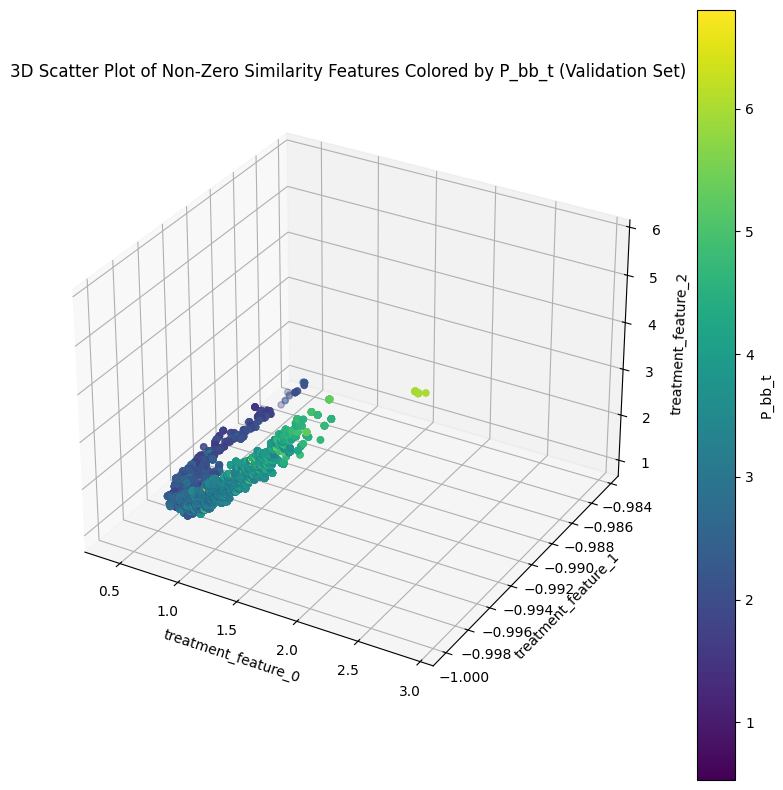

In [100]:
# plot three remaining non zero vars as 3D Scatter plot and def color gradient as Q_t

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df_full_val[controls_treatment[0]],
    df_full_val[controls_treatment[1]],
    df_full_val[controls_treatment[2]],
    c=df_full_val['P_bb_t'],
    cmap='viridis'
)

ax.set_xlabel(controls_treatment[0])
ax.set_ylabel(controls_treatment[1])
ax.set_zlabel(controls_treatment[2])
ax.set_title('3D Scatter Plot of Non-Zero Similarity Features Colored by P_bb_t (Validation Set)')

plt.colorbar(ax.collections[0], ax=ax, label='P_bb_t')
plt.show()

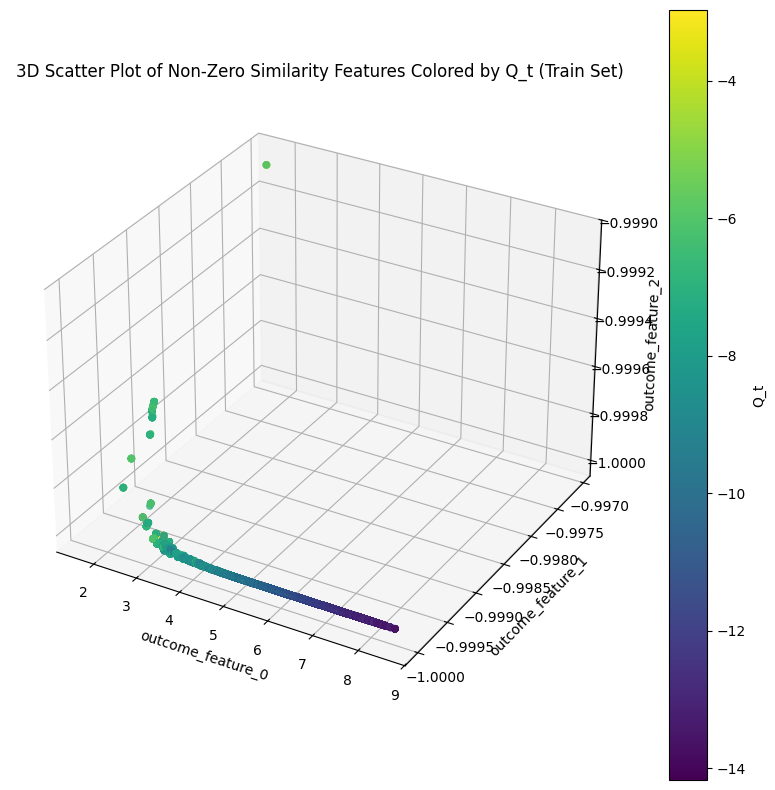

In [101]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df_full_train[controls_outcome[0]],
    df_full_train[controls_outcome[1]],
    df_full_train[controls_outcome[2]],
    c=df_full_train['Q_t'],
    cmap='viridis'
)

ax.set_xlabel(controls_outcome[0])
ax.set_ylabel(controls_outcome[1])
ax.set_zlabel(controls_outcome[2])
ax.set_title('3D Scatter Plot of Non-Zero Similarity Features Colored by Q_t (Train Set)')

plt.colorbar(ax.collections[0], ax=ax, label='Q_t')
plt.show()

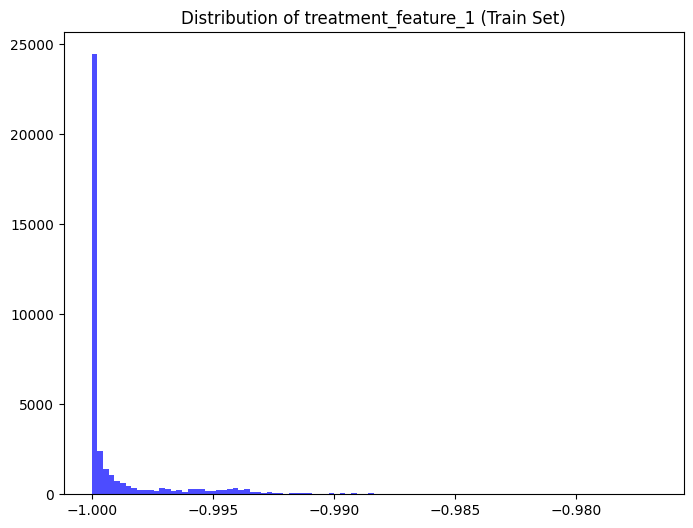

In [102]:
# for treatment_feature_1, plot histogram to see distribution
plt.figure(figsize=(8, 6))
plt.hist(df_full_train['treatment_feature_1'], bins=100, color='blue', alpha=0.7)
plt.title('Distribution of treatment_feature_1 (Train Set)')
plt.show()

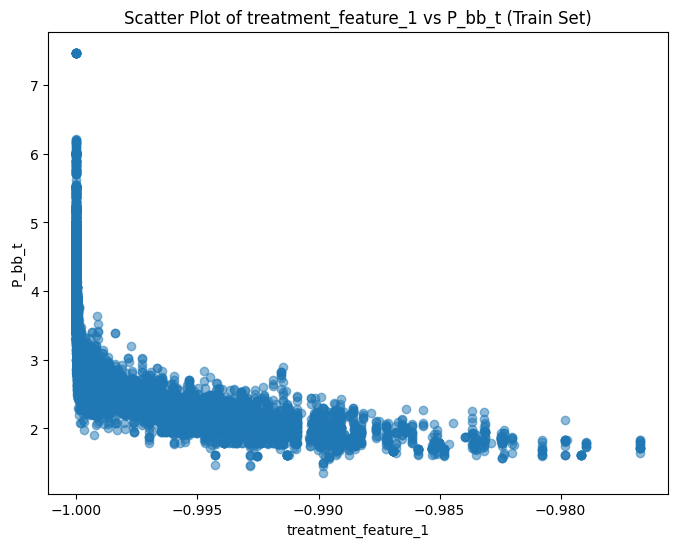

In [103]:
# scatter plot treatment_feature_1 vs P_t

plt.figure(figsize=(8, 6))
plt.scatter(df_full_train['treatment_feature_1'], df_full_train['P_bb_t'], alpha=0.5)
plt.title('Scatter Plot of treatment_feature_1 vs P_bb_t (Train Set)')
plt.xlabel('treatment_feature_1')
plt.ylabel('P_bb_t')
plt.show()

## Interactions & CATE Basis

In [104]:
basis_vars = controls_similarities + lag_1_vars
df_basis, column_transformer, column_dict = generate_basis(
    df=df_full_val,
    cols_without_scaling=controls_similarities,
    cols_to_scale=lag_1_vars,
    degree=1
)
df_basis.head()

,intercept,Q_t-1,P_bb_t-1,outcome_feature_0,outcome_feature_1,outcome_feature_2,outcome_feature_3,outcome_feature_4,treatment_feature_0,treatment_feature_1,treatment_feature_2,treatment_feature_3,treatment_feature_4
0,1.0,0.305280,0.463601,-0.139102,-6.665997e-07,-5.245164e-07,-6.745338e-07,-0.296434,-0.189208,-0.000362,-0.366351,-0.325338,-0.019359
1,1.0,0.272505,0.653600,-0.139102,-6.665997e-07,-5.245164e-07,-6.745338e-07,-0.296434,-0.189208,-0.000362,-0.366351,-0.325338,-0.019359
2,1.0,0.036240,0.687961,-0.139102,-6.665997e-07,-5.245164e-07,-6.745338e-07,-0.296434,-0.189208,-0.000362,-0.366351,-0.325338,-0.019359
3,1.0,0.025283,0.636881,-0.139102,-6.665997e-07,-5.245164e-07,-6.745338e-07,-0.296434,-0.189208,-0.000362,-0.366351,-0.325338,-0.019359
4,1.0,-0.051370,0.556816,-0.139102,-6.665997e-07,-5.245164e-07,-6.745338e-07,-0.296434,-0.189208,-0.000362,-0.366351,-0.325338,-0.019359


In [105]:
df_interact_val, interaction_vars = generate_interactions(
    df=df_full_val,
    df_basis=df_basis,
    cols_to_interact=["Q_t-1", "P_bb_t-1"])

print(f"Interactions: {interaction_vars}")
df_interact_val.columns

Interactions: ['interaction_Q_t-1_intercept', 'interaction_Q_t-1_Q_t-1', 'interaction_Q_t-1_P_bb_t-1', 'interaction_Q_t-1_outcome_feature_0', 'interaction_Q_t-1_outcome_feature_1', 'interaction_Q_t-1_outcome_feature_2', 'interaction_Q_t-1_outcome_feature_3', 'interaction_Q_t-1_outcome_feature_4', 'interaction_Q_t-1_treatment_feature_0', 'interaction_Q_t-1_treatment_feature_1', 'interaction_Q_t-1_treatment_feature_2', 'interaction_Q_t-1_treatment_feature_3', 'interaction_Q_t-1_treatment_feature_4', 'interaction_P_bb_t-1_intercept', 'interaction_P_bb_t-1_Q_t-1', 'interaction_P_bb_t-1_P_bb_t-1', 'interaction_P_bb_t-1_outcome_feature_0', 'interaction_P_bb_t-1_outcome_feature_1', 'interaction_P_bb_t-1_outcome_feature_2', 'interaction_P_bb_t-1_outcome_feature_3', 'interaction_P_bb_t-1_outcome_feature_4', 'interaction_P_bb_t-1_treatment_feature_0', 'interaction_P_bb_t-1_treatment_feature_1', 'interaction_P_bb_t-1_treatment_feature_2', 'interaction_P_bb_t-1_treatment_feature_3', 'interaction_P

Index(['ASIN', 'date', 'index', 'Q_t', 'PRICE', 'P_bb_t', 'text', 'window',
       'REVIEW_COUNT', 'RATING',
       ...
       'interaction_P_bb_t-1_outcome_feature_0',
       'interaction_P_bb_t-1_outcome_feature_1',
       'interaction_P_bb_t-1_outcome_feature_2',
       'interaction_P_bb_t-1_outcome_feature_3',
       'interaction_P_bb_t-1_outcome_feature_4',
       'interaction_P_bb_t-1_treatment_feature_0',
       'interaction_P_bb_t-1_treatment_feature_1',
       'interaction_P_bb_t-1_treatment_feature_2',
       'interaction_P_bb_t-1_treatment_feature_3',
       'interaction_P_bb_t-1_treatment_feature_4'],
      dtype='object', length=390)

## Average Effect

In [106]:
df_dynamic = df_interact_val.copy()

### Linear Models

In [107]:
def estimate_linear_model(controls):
    model = lin_model(
        df=df_dynamic,
        outcome=outcome,
        treatments=base_treatment,
        controls=controls,
        level=confidence_level,
        cov_type="cluster",
        cov_kwds={"groups": df_dynamic["ASIN"]},
    )
    return model

In [108]:
estimate_linear_model(controls=[])

Adjusted R^2: 0.0027
          coef  std err        t  P>|t|   [5.0%  95.0%]
const  -10.756    0.104 -103.858  0.000 -10.926 -10.586
P_bb_t  -0.111    0.033   -3.384  0.001  -0.164  -0.057


,lower,upper,coef
P_bb_t,-0.164462,-0.056884,-0.110673


In [109]:
ci_linear_base_lagged = estimate_linear_model(controls=lag_1_vars)

Adjusted R^2: 0.8835
           coef  std err        t  P>|t|  [5.0%  95.0%]
const    -0.677    0.034  -19.935    0.0 -0.733  -0.621
P_bb_t   -0.690    0.040  -17.248    0.0 -0.756  -0.624
Q_t-1     0.936    0.003  321.411    0.0  0.931   0.941
P_bb_t-1  0.678    0.040   16.995    0.0  0.613   0.744


In [110]:
ci_linear_embeddings = estimate_linear_model(controls=lag_1_vars + embeddings)

Adjusted R^2: 0.8886
           coef  std err        t  P>|t|  [5.0%  95.0%]
const    -1.306    0.059  -22.130  0.000 -1.403  -1.209
P_bb_t   -0.661    0.039  -16.808  0.000 -0.726  -0.597
Q_t-1     0.861    0.005  159.271  0.000  0.853   0.870
P_bb_t-1  0.596    0.039   15.221  0.000  0.532   0.661
emb_0    -2.110    1.113   -1.897  0.058 -3.941  -0.280
...         ...      ...      ...    ...    ...     ...
emb_251   0.269    0.136    1.975  0.048  0.045   0.494
emb_252   0.158    0.127    1.248  0.212 -0.050   0.367
emb_253   0.207    0.142    1.451  0.147 -0.028   0.441
emb_254   0.232    0.145    1.606  0.108 -0.006   0.470
emb_255  -0.202    0.136   -1.484  0.138 -0.425   0.022

[260 rows x 6 columns]


In [111]:
ci_linear_base_lagged_add_controls = estimate_linear_model(controls=lag_1_vars + additional_controls)

Adjusted R^2: 0.8929
                                           coef  std err        t  P>|t|  \
const                                    -0.994    0.052  -19.158  0.000   
P_bb_t                                   -0.756    0.040  -19.108  0.000   
Q_t-1                                     0.925    0.003  279.445  0.000   
P_bb_t-1                                  0.714    0.039   18.172  0.000   
RATING_t-1                                0.031    0.007    4.726  0.000   
REVIEW_COUNT_t-1                          0.000    0.000    8.631  0.000   
New Offer Count: Current                 -0.001    0.001   -1.395  0.163   
Count of retrieved live offers: New, FBA  0.005    0.001    3.481  0.001   
Count of retrieved live offers: New, FBM -0.004    0.001   -3.962  0.000   
weighted_substitute_price                 0.027    0.007    4.055  0.000   
Cars & Race Cars                          0.023    0.006    3.917  0.000   
Trains & Trams                            0.053    0.014    3.826  

In [112]:
ci_linear_base_lagged_add_controls_emb = estimate_linear_model(controls=lag_1_vars + additional_controls + embeddings)

Adjusted R^2: 0.897
             coef  std err        t  P>|t|  [5.0%  95.0%]
const      -1.641    0.083  -19.782  0.000 -1.777  -1.504
P_bb_t     -0.718    0.039  -18.513  0.000 -0.782  -0.654
Q_t-1       0.858    0.006  149.527  0.000  0.849   0.868
P_bb_t-1    0.652    0.039   16.863  0.000  0.588   0.715
RATING_t-1  0.029    0.008    3.880  0.000  0.017   0.042
...           ...      ...      ...    ...    ...     ...
emb_251     0.191    0.137    1.396  0.163 -0.034   0.417
emb_252     0.181    0.124    1.459  0.145 -0.023   0.385
emb_253     0.144    0.141    1.020  0.308 -0.088   0.376
emb_254     0.177    0.143    1.240  0.215 -0.058   0.412
emb_255    -0.202    0.135   -1.497  0.134 -0.424   0.020

[289 rows x 6 columns]


In [113]:
ci_linear_base_lagged_add_controls_sim = estimate_linear_model(controls=lag_1_vars + controls_similarities + additional_controls)

Adjusted R^2: 0.8967
                                               coef   std err        t  P>|t|  \
const                                     -3899.699  1552.176   -2.512  0.012   
P_bb_t                                       -0.723     0.038  -18.772  0.000   
Q_t-1                                         0.865     0.006  147.920  0.000   
P_bb_t-1                                      0.663     0.038   17.283  0.000   
outcome_feature_0                            -0.108     0.023   -4.725  0.000   
outcome_feature_1                          1893.734  3588.666    0.528  0.598   
outcome_feature_2                        -12131.424  5026.009   -2.414  0.016   
outcome_feature_3                          6327.791  4008.593    1.579  0.114   
outcome_feature_4                            -0.033     0.012   -2.642  0.008   
treatment_feature_0                          -0.151     0.060   -2.521  0.012   
treatment_feature_1                          10.955     3.379    3.242  0.001   
treatme

In [114]:
ci_linear_interactions = estimate_linear_model(controls=interaction_vars + controls_similarities + additional_controls)

Adjusted R^2: 0.8972
                                     coef    std err       t  P>|t|  \
const                          -29242.337  25205.910  -1.160  0.246   
P_bb_t                             -0.731      0.039 -18.995  0.000   
interaction_Q_t-1_intercept         0.578      0.046  12.574  0.000   
interaction_Q_t-1_Q_t-1            -0.011      0.006  -1.884  0.060   
interaction_Q_t-1_P_bb_t-1         -0.046      0.002 -19.995  0.000   
...                                   ...        ...     ...    ...   
2023-12-04                          0.275      0.009  29.783  0.000   
2024-01-01                          0.111      0.010  10.958  0.000   
2024-01-29                         -0.247      0.010 -23.834  0.000   
Lightning Deals: Upcoming Deal      0.311      0.095   3.264  0.001   
Buy Box: Is FBA                     0.019      0.007   2.908  0.004   

                                    [5.0%     95.0%]  
const                          -70702.369  12217.695  
P_bb_t          

In [115]:
ci_linear_base_lagged['model'] = 'Linear lagged'
ci_linear_embeddings['model'] = 'Linear lagged_and_embeddings'
ci_linear_base_lagged_add_controls['model'] = 'Linear lagged_and_add_controls'
ci_linear_base_lagged_add_controls_emb['model'] = 'Linear lagged_and_add_controls_and_emb'
ci_linear_base_lagged_add_controls_sim['model'] = 'Linear lagged_and_add_controls_and_ReLU_features'
ci_linear_interactions['model'] = 'Linear interactions'

df_base = pd.concat([
    ci_linear_base_lagged,
    ci_linear_embeddings,
    ci_linear_base_lagged_add_controls,
    ci_linear_base_lagged_add_controls_emb,
    ci_linear_base_lagged_add_controls_sim
], ignore_index=True)

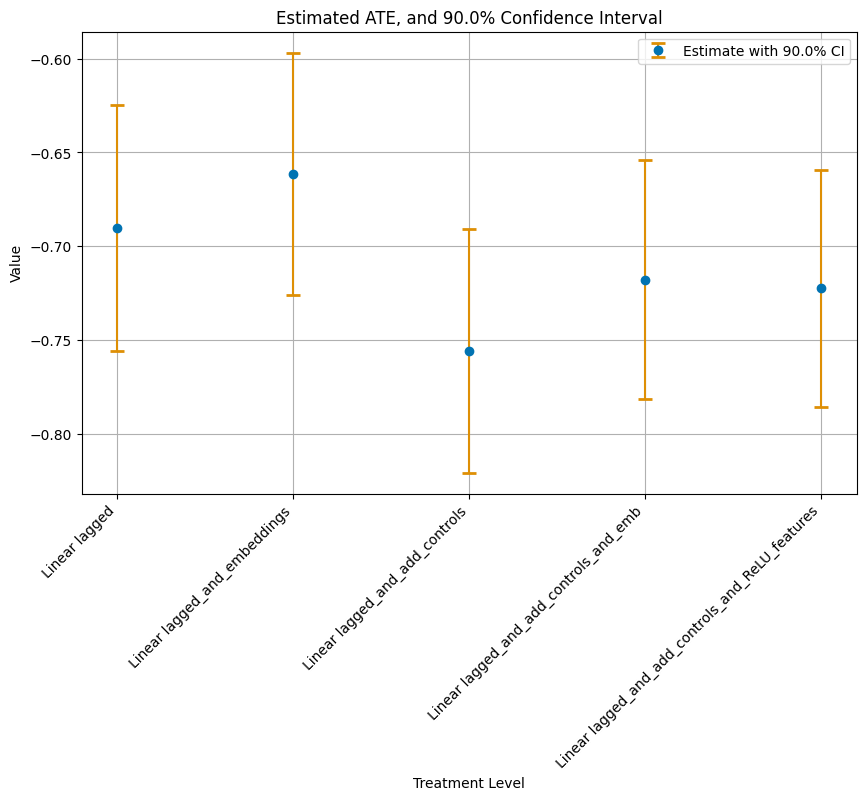

In [116]:

# Plotting
plt.figure(figsize=(10, 6))
# Plot Estimate with CI
plt.errorbar(df_base['model'], df_base['coef'],
             yerr=[df_base['coef'] - df_base['lower'], df_base['upper'] - df_base['coef']],
             fmt='o', capsize=5, capthick=2, ecolor=palette[1], color=palette[0], label=f'Estimate with {round(confidence_level*100, 1)}% CI', zorder=2)

plt.title(f'Estimated ATE, and {round(confidence_level*100, 1)}% Confidence Interval')
plt.xlabel('Treatment Level')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, f'linear_ate_estimates.png'))
plt.show()

In [117]:
df_base

,lower,upper,coef,model
0,-0.756093,-0.624438,-0.690266,Linear lagged
1,-0.726154,-0.596700,-0.661427,Linear lagged_and_embeddings
2,-0.820821,-0.690707,-0.755764,Linear lagged_and_add_controls
3,-0.781564,-0.654014,-0.717789,Linear lagged_and_add_controls_and_emb
4,-0.785870,-0.659242,-0.722556,Linear lagged_and_add_controls_and_ReLU_features


### DML Models

In [118]:
ml_g = LGBMRegressor(n_estimators=500, lr=0.02, random_state=42, verbose=-1)
ml_m = LGBMRegressor(n_estimators=500, lr=0.02, random_state=42, verbose=-1)

def r2(y_true, y_pred):
    subset = np.logical_not(np.isnan(y_true))
    return r2_score(y_true[subset], y_pred[subset])

def estimate_dml_model(controls):
    tab_dml_data = dml.DoubleMLClusterData(
        df_dynamic,
        y_col=outcome[0],
        d_cols=base_treatment,
        x_cols=controls,
        cluster_cols="ASIN")

    np.random.seed(3141)
    tab_dml_obj = dml.DoubleMLPLR(tab_dml_data, ml_g, ml_m)
    tab_dml_obj.fit()

    tab_summary_df = summarize_dml(tab_dml_obj, level=confidence_level)
    ci_tab_dml = tab_summary_df[ci_names + ['coef']]
    ci_tab_dml.columns = ['lower', 'upper', 'coef']

    r2_scores = tab_dml_obj.evaluate_learners(metric=r2)
    print(f"R2 Outcome: {round(r2_scores['ml_l'][0, 0],4)} R2 Treatment: {round(r2_scores['ml_m'][0, 0],4)}\n")

    return tab_dml_obj, ci_tab_dml

In [119]:
tab_dml_obj_embeddings, ci_tab_dml_embeddings = estimate_dml_model(controls=lag_1_vars + embeddings)

C:\Users\Work\AppData\Local\Temp\ipykernel_36508\3595506967.py:9: FutureWarning: DoubleMLClusterData is deprecated and will be removed with version 0.12.0. Use DoubleMLData with cluster_cols instead.
  tab_dml_data = dml.DoubleMLClusterData(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'e

         coef  std err       t  P>|t|   5.0%  95.0%
P_bb_t -0.641    0.045 -14.286    0.0 -0.715 -0.567
R2 Outcome: 0.8662 R2 Treatment: 0.974



In [120]:
tab_dml_obj_add_controls, ci_tab_dml_add_controls = estimate_dml_model(controls=lag_1_vars + additional_controls)

C:\Users\Work\AppData\Local\Temp\ipykernel_36508\3595506967.py:9: FutureWarning: DoubleMLClusterData is deprecated and will be removed with version 0.12.0. Use DoubleMLData with cluster_cols instead.
  tab_dml_data = dml.DoubleMLClusterData(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'e

         coef  std err       t  P>|t|   5.0%  95.0%
P_bb_t -0.746    0.047 -15.985    0.0 -0.823 -0.669
R2 Outcome: 0.8972 R2 Treatment: 0.9774



In [121]:
tab_dml_obj_embeddings_add_controls, ci_tab_dml_embeddings_add_controls = estimate_dml_model(controls=lag_1_vars + embeddings + additional_controls)

C:\Users\Work\AppData\Local\Temp\ipykernel_36508\3595506967.py:9: FutureWarning: DoubleMLClusterData is deprecated and will be removed with version 0.12.0. Use DoubleMLData with cluster_cols instead.
  tab_dml_data = dml.DoubleMLClusterData(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'e

         coef  std err       t  P>|t|   5.0%  95.0%
P_bb_t -0.691    0.042 -16.338    0.0 -0.761 -0.621
R2 Outcome: 0.8942 R2 Treatment: 0.9753



In [122]:
tab_dml_obj_sim_add_controls, ci_tab_dml_sim_add_controls = estimate_dml_model(controls=lag_1_vars + controls_similarities + additional_controls)

C:\Users\Work\AppData\Local\Temp\ipykernel_36508\3595506967.py:9: FutureWarning: DoubleMLClusterData is deprecated and will be removed with version 0.12.0. Use DoubleMLData with cluster_cols instead.
  tab_dml_data = dml.DoubleMLClusterData(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'e

         coef  std err       t  P>|t|   5.0%  95.0%
P_bb_t -0.712    0.042 -16.827    0.0 -0.781 -0.642
R2 Outcome: 0.8996 R2 Treatment: 0.9772



In [123]:
tab_dml_obj_pca_add_controls, ci_tab_dml_pca_add_controls = estimate_dml_model(controls=lag_1_vars + controls_pca + additional_controls)

C:\Users\Work\AppData\Local\Temp\ipykernel_36508\3595506967.py:9: FutureWarning: DoubleMLClusterData is deprecated and will be removed with version 0.12.0. Use DoubleMLData with cluster_cols instead.
  tab_dml_data = dml.DoubleMLClusterData(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'e

         coef  std err       t  P>|t|   5.0%  95.0%
P_bb_t -0.696    0.042 -16.427    0.0 -0.766 -0.627
R2 Outcome: 0.8993 R2 Treatment: 0.9769



### Visualization

In [124]:
ci_tab_dml_embeddings['model'] = 'plr_embeddings'
ci_tab_dml_add_controls['model'] = 'plr_add_controls'
ci_tab_dml_embeddings_add_controls['model'] = 'plr_embeddings_add_controls'
ci_tab_dml_sim_add_controls['model'] = 'plr_ReLU_feat_add_controls'
ci_tab_dml_pca_add_controls['model'] = 'plr_pca_add_controls'


df_averages = pd.concat([
    ci_tab_dml_embeddings,
    ci_tab_dml_add_controls,
    ci_tab_dml_embeddings_add_controls,
    ci_tab_dml_sim_add_controls,
    ci_tab_dml_pca_add_controls
], ignore_index=True)

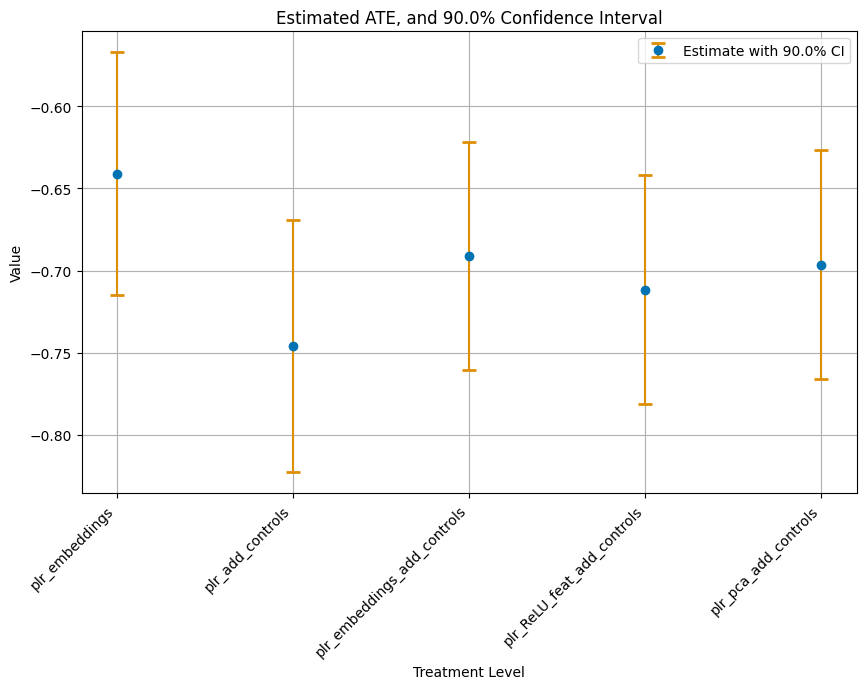

In [125]:

# Plotting
plt.figure(figsize=(10, 6))
# Plot Estimate with CI
plt.errorbar(df_averages['model'], df_averages['coef'],
             yerr=[df_averages['coef'] - df_averages['lower'], df_averages['upper'] - df_averages['coef']],
             fmt='o', capsize=5, capthick=2, ecolor=palette[1], color=palette[0], label=f'Estimate with {round(confidence_level*100, 1)}% CI', zorder=2)

plt.title(f'Estimated ATE, and {round(confidence_level*100, 1)}% Confidence Interval')
plt.xlabel('Treatment Level')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, f'plr_ate_estimates.png'))
plt.show()

## GATEs

In [126]:
df_dynamic[controls_similarities]

,outcome_feature_0,outcome_feature_1,outcome_feature_2,outcome_feature_3,outcome_feature_4,treatment_feature_0,treatment_feature_1,treatment_feature_2,treatment_feature_3,treatment_feature_4
0,6.275250,-1.0,-1.0,-1.0,13.819509,0.927130,-0.999649,1.954074,1.263811,-0.971074
1,6.275250,-1.0,-1.0,-1.0,13.819509,0.927130,-0.999649,1.954074,1.263811,-0.971074
2,6.275250,-1.0,-1.0,-1.0,13.819509,0.927130,-0.999649,1.954074,1.263811,-0.971074
3,6.275250,-1.0,-1.0,-1.0,13.819509,0.927130,-0.999649,1.954074,1.263811,-0.971074
4,6.275250,-1.0,-1.0,-1.0,13.819509,0.927130,-0.999649,1.954074,1.263811,-0.971074
...,...,...,...,...,...,...,...,...,...,...
38036,6.314475,-1.0,-1.0,-1.0,13.891903,1.305544,-0.999991,2.573110,1.951898,-0.996732
38037,6.780542,-1.0,-1.0,-1.0,14.732714,1.006196,-0.999801,2.011269,1.405911,-0.978818
38038,6.704156,-1.0,-1.0,-1.0,14.530434,0.998061,-0.999788,1.996408,1.392583,-0.978115
38039,5.416586,-1.0,-1.0,-1.0,12.737415,0.574239,-0.995385,1.387585,0.951113,-0.721984


0
outcome_feature_4    38041
dtype: int64


c:\Users\Work\.conda\envs\dml_dev\Lib\site-packages\matplotlib\cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


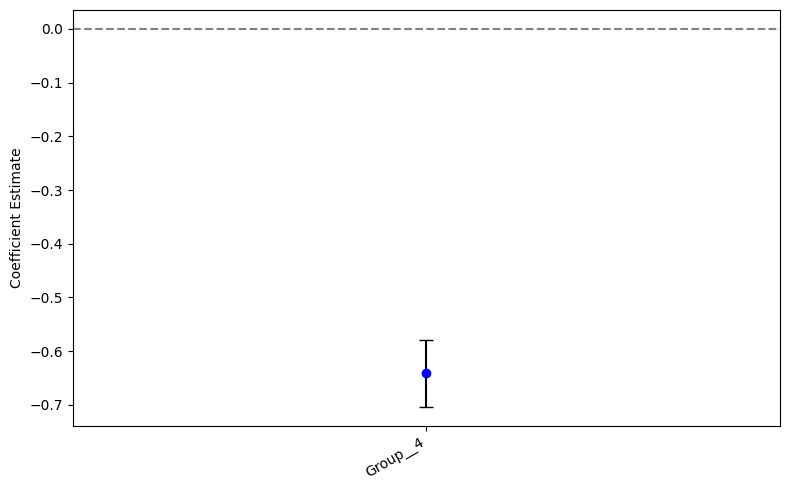

In [127]:
groups = pd.DataFrame(df_dynamic[controls_similarities].idxmax(axis=1))

print(groups.groupby(0).size())
gates_0 = tab_dml_obj_embeddings.gate(groups)
gates_0_summ = gates_0.summary
gates_0_summ["err_lower"] = gates_0_summ["coef"] - gates_0_summ["[0.025"]
gates_0_summ["err_upper"] = gates_0_summ["0.975]"] - gates_0_summ["coef"]

# Positions on the x-axis
x_vals = range(len(gates_0_summ))

plt.figure(figsize=(8, 5))
plt.errorbar(
    x=x_vals,
    y=gates_0_summ["coef"],
    yerr=[gates_0_summ["err_lower"], gates_0_summ["err_upper"]],
    fmt='o',
    capsize=5,
    color='blue',
    ecolor='black'
)

# Draw a zero line for reference
plt.axhline(y=0, color='gray', linestyle='--')

# Customizing x-axis labels
plt.xticks(ticks=x_vals, labels=[gr.replace("outcome_feature", "") for gr in gates_0_summ.index], rotation=30, ha='right')
plt.ylabel("Coefficient Estimate")
plt.tight_layout()
plt.show()

## CATEs

In [128]:
uniform_ci = True  # False | True

In [129]:
cate_controls = lag_1_vars + embeddings + additional_controls
cate_controls_interactions = cate_controls + interaction_vars

plr_obj = tab_dml_obj_embeddings_add_controls

In [130]:
# clear RAM to avoid OOM issues
import gc
gc.collect()

20321

In [131]:
cate_kwargs_val = {
    'cov_type': 'cluster',
    'cov_kwds': {'groups': df_dynamic["ASIN"]}
}

cate_models_polynomial = {
    'Linear Specification': None,
    'Linear Specification (Interactions)': None,
    'PLR Specification': None,
}

# Linear Models
cate_models_polynomial['Linear Specification'] = lin_model_cate(
    df=df_dynamic,
    outcome=outcome,
    basis=df_basis,
    treatment=base_treatment,
    controls=cate_controls,
    **cate_kwargs_val,
)

print(f"\nLinear Specification")
df_specification_1 = summarize_lin_model(cate_models_polynomial['Linear Specification'], level=confidence_level)
print("=" * 80)#

cate_models_polynomial['Linear Specification (Interactions)'] = lin_model_cate(
    df=df_dynamic,
    outcome=outcome,
    basis=df_basis,
    treatment=base_treatment,
    controls=cate_controls_interactions,
    **cate_kwargs_val,
)

print(f"\nLinear specification with interactions")
df_specification_2 = summarize_lin_model(cate_models_polynomial['Linear Specification (Interactions)'], level=confidence_level)
print("=" * 80)

# tabular DML model
cate_models_polynomial['PLR Specification'] = plr_obj.cate(
    df_basis, **cate_kwargs_val
)

print(f"\nTabular DML PLR Specification")
df_specification_3 = summarize_lin_model(
    cate_models_polynomial['PLR Specification'].blp_model, level=confidence_level
)
print("=" * 80)



Linear Specification
                          coef    std err       t  P>|t|        5.0%  \
intercept               -0.705      0.040 -17.772  0.000      -0.771   
Q_t-1                   -0.178      0.059  -3.021  0.003      -0.275   
P_bb_t-1                 0.006      0.054   0.117  0.907      -0.082   
outcome_feature_0       -0.165      0.378  -0.436  0.663      -0.786   
outcome_feature_1    70928.106  46872.555   1.513  0.130   -6170.385   
outcome_feature_2   -83418.079  65894.910  -1.266  0.206 -191805.561   
outcome_feature_3    -1696.613  42986.921  -0.039  0.969  -72403.806   
outcome_feature_4        0.112      0.201   0.555  0.579      -0.219   
treatment_feature_0     -2.367      0.943  -2.510  0.012      -3.917   
treatment_feature_1      0.083     45.199   0.002  0.999     -74.262   
treatment_feature_2      0.899      0.436   2.063  0.039       0.182   
treatment_feature_3      0.178      0.521   0.341  0.733      -0.680   
treatment_feature_4     -0.788      1.196 

In [132]:
cate_models_polynomial['Linear Specification (Interactions)'].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.025
Model:                            OLS   Adj. R-squared (uncentered):              0.025
Method:                 Least Squares   F-statistic:                              33.62
Date:                Wed, 05 Nov 2025   Prob (F-statistic):                    2.74e-80
Time:                        15:55:42   Log-Likelihood:                         -20898.
No. Observations:               38041   AIC:                                  4.182e+04
Df Residuals:                   38028   BIC:                                  4.193e+04
Df Model:                          13                                                  
Covariance Type:              cluster                                                  
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
intercept              -0.7094      0.040    -17.912      0.000      -0.787      -0.632
Q_t-1                  -0.1934      0.058     -3.309      0.001      -0.308      -0.079
P_bb_t-1                0.0017      0.055      0.032      0.975      -0.106       0.109
outcome_feature_0      -0.1807      0.376     -0.480      0.631      -0.918       0.557
outcome_feature_1    5.022e+04   4.54e+04      1.107      0.268   -3.87e+04    1.39e+05
outcome_feature_2   -6.297e+04   6.02e+04     -1.046      0.296   -1.81e+05    5.51e+04
outcome_feature_3    2146.9258   3.98e+04      0.054      0.957   -7.59e+04    8.02e+04
outcome_feature_4       0.1072      0.201      0.535      0.593      -0.286       0.500
treatment_feature_0    -2.4176      0.932     -2.594      0.009      -4.244      -0.591
treatment_feature_1     2.1977     45.029      0.049      0.961     -86.057      90.452
treatment_feature_2     0.8893      0.436      2.040      0.041       0.035       1.743
treatment_feature_3     0.2224      0.522      0.426      0.670      -0.800       1.245
treatment_feature_4    -0.9208      1.192     -0.773      0.440      -3.257       1.415
==============================================================================
Omnibus:                    12116.250   Durbin-Watson:                   1.987
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           711373.614
Skew:                           0.718   Prob(JB):                         0.00
Kurtosis:                      24.136   Cond. No.                     3.99e+06
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors are robust to cluster correlation (cluster)
[3] The smallest eigenvalue is 5.31e-11. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [133]:
cate_models_polynomial['PLR Specification'].blp_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.031
Model:                            OLS   Adj. R-squared (uncentered):              0.030
Method:                 Least Squares   F-statistic:                              33.23
Date:                Wed, 05 Nov 2025   Prob (F-statistic):                    2.53e-79
Time:                        15:55:42   Log-Likelihood:                         -21144.
No. Observations:               38041   AIC:                                  4.231e+04
Df Residuals:                   38028   BIC:                                  4.243e+04
Df Model:                          13                                                  
Covariance Type:              cluster                                                  
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
intercept              -0.7079      0.042    -16.866      0.000      -0.790      -0.626
Q_t-1                  -0.2842      0.088     -3.224      0.001      -0.457      -0.111
P_bb_t-1               -0.0461      0.033     -1.384      0.166      -0.111       0.019
outcome_feature_0      -0.2726      0.377     -0.722      0.470      -1.012       0.467
outcome_feature_1    5725.1050   5.33e+04      0.107      0.914   -9.87e+04     1.1e+05
outcome_feature_2   -7.094e+04   4.25e+04     -1.669      0.095   -1.54e+05    1.23e+04
outcome_feature_3    4.592e+04   2.85e+04      1.608      0.108      -1e+04    1.02e+05
outcome_feature_4       0.1057      0.196      0.538      0.590      -0.279       0.491
treatment_feature_0    -3.2997      0.889     -3.712      0.000      -5.042      -1.557
treatment_feature_1    11.5265     45.869      0.251      0.802     -78.375     101.428
treatment_feature_2     1.0182      0.371      2.746      0.006       0.291       1.745
treatment_feature_3     0.6510      0.427      1.524      0.128      -0.186       1.488
treatment_feature_4    -1.3745      1.130     -1.217      0.224      -3.589       0.840
==============================================================================
Omnibus:                    14373.383   Durbin-Watson:                   1.587
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           533212.587
Skew:                           1.145   Prob(JB):                         0.00
Kurtosis:                      21.198   Cond. No.                     4.87e+06
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors are robust to cluster correlation (cluster)
[3] The smallest eigenvalue is 5.62e-11. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [134]:
df_full_train[[v for v in df_full_train.columns if "sim" in v]].corr()

,similarity_cluster_0,similarity_cluster_1,similarity_cluster_2,similarity_cluster_3,similarity_cluster_4
similarity_cluster_0,1.000000,-0.891024,-0.434484,-0.136023,0.391589
similarity_cluster_1,-0.891024,1.000000,0.130029,0.457330,-0.708226
similarity_cluster_2,-0.434484,0.130029,1.000000,-0.817561,0.538156
similarity_cluster_3,-0.136023,0.457330,-0.817561,1.000000,-0.905297
similarity_cluster_4,0.391589,-0.708226,0.538156,-0.905297,1.000000


In [135]:
df_full_val[[v for v in df_full_val.columns if "sim" in v]].corr()

,similarity_cluster_0,similarity_cluster_1,similarity_cluster_2,similarity_cluster_3,similarity_cluster_4
similarity_cluster_0,1.000000,-0.897450,-0.386910,-0.194286,0.450644
similarity_cluster_1,-0.897450,1.000000,0.122339,0.475066,-0.738064
similarity_cluster_2,-0.386910,0.122339,1.000000,-0.809949,0.488724
similarity_cluster_3,-0.194286,0.475066,-0.809949,1.000000,-0.883130
similarity_cluster_4,0.450644,-0.738064,0.488724,-0.883130,1.000000


In [136]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def vif(df_sim):
    vif_data = pd.DataFrame()
    vif_data["feature"] = df_sim.columns
    vif_data["VIF"] = [variance_inflation_factor(df_sim.values, i)
                            for i in range(len(df_sim.columns))]
    print(vif_data)

In [137]:
vif(df_full_train[[v for v in df_full_train.columns if "sim" in v]])

                feature          VIF
0  similarity_cluster_0   387.321873
1  similarity_cluster_1   216.657076
2  similarity_cluster_2  4672.873596
3  similarity_cluster_3  7659.813233
4  similarity_cluster_4   637.144618


In [138]:
vif(df_full_val[[v for v in df_full_val.columns if "sim" in v]])

                feature          VIF
0  similarity_cluster_0   320.205451
1  similarity_cluster_1   183.169615
2  similarity_cluster_2  3824.697810
3  similarity_cluster_3  6350.899635
4  similarity_cluster_4   529.233311


In [139]:
vif(df_full_train[[v for v in df_full_train.columns if "pca" in v]])

  feature       VIF
0   pca_0  1.003370
1   pca_1  1.007021
2   pca_2  1.006397
3   pca_3  1.002298
4   pca_4  1.005737


In [140]:
vif(df_full_val[[v for v in df_full_val.columns if "pca" in v]])

  feature       VIF
0   pca_0  1.004358
1   pca_1  1.007831
2   pca_2  1.006987
3   pca_3  1.002203
4   pca_4  1.006035


In [141]:
latex_args = {
    'index': True,
    'float_format': "%.3f",
    'column_format': "lcccccc",
}

print(df_specification_1.to_latex(**latex_args))
print(df_specification_2.to_latex(**latex_args))
print(df_specification_3.to_latex(**latex_args))

\begin{tabular}{lcccccc}
\toprule
 & coef & std err & t & P>|t| & 5.0% & 95.0% \\
\midrule
intercept & -0.705 & 0.040 & -17.772 & 0.000 & -0.771 & -0.640 \\
Q_t-1 & -0.178 & 0.059 & -3.021 & 0.003 & -0.275 & -0.081 \\
P_bb_t-1 & 0.006 & 0.054 & 0.117 & 0.907 & -0.082 & 0.094 \\
outcome_feature_0 & -0.165 & 0.378 & -0.436 & 0.663 & -0.786 & 0.457 \\
outcome_feature_1 & 70928.106 & 46872.555 & 1.513 & 0.130 & -6170.385 & 148026.597 \\
outcome_feature_2 & -83418.079 & 65894.910 & -1.266 & 0.206 & -191805.561 & 24969.403 \\
outcome_feature_3 & -1696.613 & 42986.921 & -0.039 & 0.969 & -72403.806 & 69010.580 \\
outcome_feature_4 & 0.112 & 0.201 & 0.555 & 0.579 & -0.219 & 0.442 \\
treatment_feature_0 & -2.367 & 0.943 & -2.510 & 0.012 & -3.917 & -0.816 \\
treatment_feature_1 & 0.083 & 45.199 & 0.002 & 0.999 & -74.262 & 74.428 \\
treatment_feature_2 & 0.899 & 0.436 & 2.063 & 0.039 & 0.182 & 1.615 \\
treatment_feature_3 & 0.178 & 0.521 & 0.341 & 0.733 & -0.680 & 1.036 \\
treatment_feature_4 & -0

In [142]:
summary_list = []
for model_name, model in cate_models_polynomial.items():
    if "Linear" in model_name:
        tmp_summary = summarize_lin_model(model, level=confidence_level)
    else:
        tmp_summary = summarize_lin_model(model.blp_model, level=confidence_level)
    for index, row in tmp_summary.iterrows():
        variable = index
        summary_list.append(
            {
                "model": model_name,
                "variable": variable,
                "coef": row["coef"],
                "Std.Err.": row["std err"],
                "lower": row[ci_names[0]],  # Adjusted to match the column name
                "upper": row[ci_names[1]],  # Adjusted to match the column name
            }
        )

cate_summary_df = pd.DataFrame(summary_list)

                          coef    std err       t  P>|t|        5.0%  \
intercept               -0.705      0.040 -17.772  0.000      -0.771   
Q_t-1                   -0.178      0.059  -3.021  0.003      -0.275   
P_bb_t-1                 0.006      0.054   0.117  0.907      -0.082   
outcome_feature_0       -0.165      0.378  -0.436  0.663      -0.786   
outcome_feature_1    70928.106  46872.555   1.513  0.130   -6170.385   
outcome_feature_2   -83418.079  65894.910  -1.266  0.206 -191805.561   
outcome_feature_3    -1696.613  42986.921  -0.039  0.969  -72403.806   
outcome_feature_4        0.112      0.201   0.555  0.579      -0.219   
treatment_feature_0     -2.367      0.943  -2.510  0.012      -3.917   
treatment_feature_1      0.083     45.199   0.002  0.999     -74.262   
treatment_feature_2      0.899      0.436   2.063  0.039       0.182   
treatment_feature_3      0.178      0.521   0.341  0.733      -0.680   
treatment_feature_4     -0.788      1.196  -0.659  0.510      -2

In [143]:
cate_summary_df

,model,variable,coef,Std.Err.,lower,upper
0,Linear Specification,intercept,-0.705328,0.039688,-0.770609,-0.640047
1,Linear Specification,Q_t-1,-0.177852,0.058865,-0.274676,-0.081028
2,Linear Specification,P_bb_t-1,0.006288,0.053587,-0.081854,0.094430
3,Linear Specification,outcome_feature_0,-0.164661,0.377743,-0.785993,0.456671
4,Linear Specification,outcome_feature_1,70928.105949,46872.554540,-6170.385391,148026.597289
5,Linear Specification,outcome_feature_2,-83418.079058,65894.910116,-191805.560959,24969.402843
6,Linear Specification,outcome_feature_3,-1696.613021,42986.920924,-72403.805815,69010.579772
7,Linear Specification,outcome_feature_4,0.111591,0.200945,-0.218934,0.442117
8,Linear Specification,treatment_feature_0,-2.366548,0.942810,-3.917333,-0.815763
9,Linear Specification,treatment_feature_1,0.083197,45.198625,-74.261925,74.428319


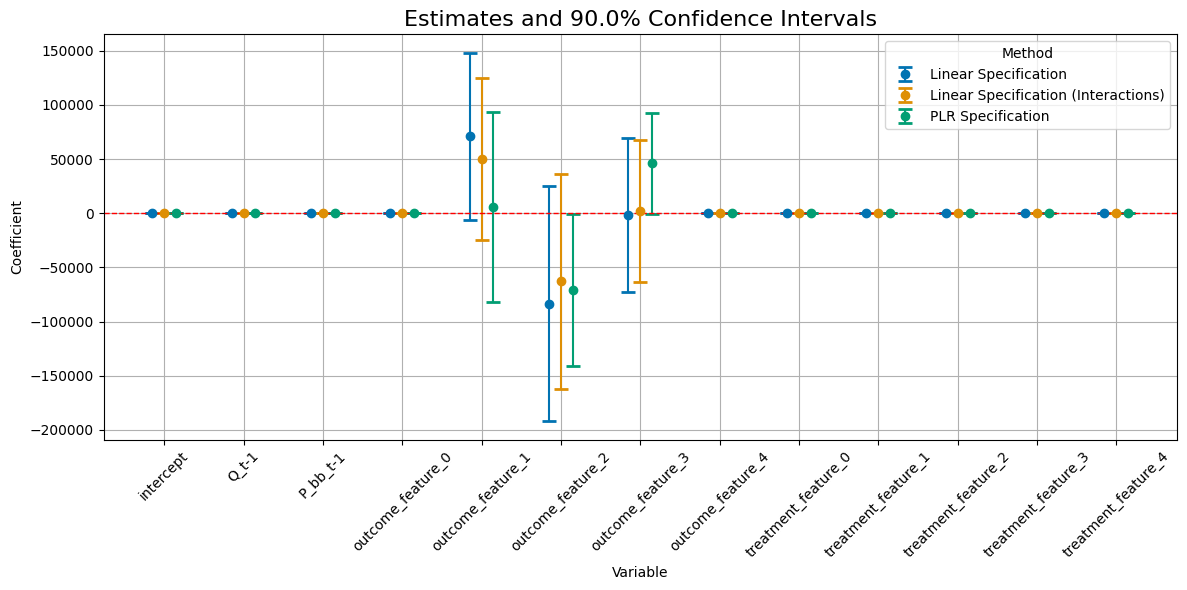

In [144]:
models = cate_summary_df["model"].unique()
variables = cate_summary_df["variable"].unique()
plt.figure(figsize=(12, 6))
bar_width = 0.15
x_positions = np.arange(len(variables))
for i, model in enumerate(models):
    df_model = cate_summary_df[cate_summary_df["model"] == model]
    if not df_model.empty:
        plt.errorbar(
            x_positions + i * bar_width,
            df_model["coef"],
            yerr=[
                df_model["coef"] - df_model["lower"],
                df_model["upper"] - df_model["coef"],
            ],
            fmt="o",
            label=model,
            capsize=5,
            capthick=2,
            ecolor=palette[i % len(palette)],
            color=palette[i % len(palette)],
            zorder=2,
        )
plt.xticks(x_positions + (len(models) - 1) * bar_width / 2, variables, rotation=45)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title(f"Estimates and {ci_level_name} Confidence Intervals", fontsize=16)
plt.xlabel("Variable")
plt.ylabel("Coefficient")
plt.legend(title="Method")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"cluster_and_level_cate_estimates.png"))
plt.show()

### $R^2$

In [145]:
alpha_x_lin = cate_models_polynomial["Linear Specification"].predict(df_basis)
alpha_x_lin_interactions = cate_models_polynomial["Linear Specification (Interactions)"].predict(df_basis)
alpha_x_plr = cate_models_polynomial["PLR Specification"].blp_model.predict(df_basis)


print("Linear Specification")
model_lin_emb = sm.OLS(alpha_x_lin, sm.add_constant(df_dynamic[embeddings])).fit()
model_lin_sim = sm.OLS(alpha_x_lin, sm.add_constant(df_dynamic[controls_similarities])).fit()
model_lin_lvl = sm.OLS(alpha_x_lin, sm.add_constant(df_dynamic[lag_1_vars])).fit()

print("Variance explained by embeddings: ", model_lin_emb.rsquared)
print("Variance explained by similarities: ", model_lin_sim.rsquared)
print("Variance explained by lagged variables: ", model_lin_lvl.rsquared)

print("Linear Specification with interactions")
model_lin_interactions_emb = sm.OLS(alpha_x_lin_interactions, sm.add_constant(df_dynamic[embeddings])).fit()
model_lin_interactions_sim = sm.OLS(alpha_x_lin_interactions, sm.add_constant(df_dynamic[controls_similarities])).fit()
model_lin_interactions_lvl = sm.OLS(alpha_x_lin_interactions, sm.add_constant(df_dynamic[lag_1_vars])).fit()
print("Variance explained by embeddings: ", model_lin_interactions_emb.rsquared)
print("Variance explained by similarities: ", model_lin_interactions_sim.rsquared)
print("Variance explained by lagged variables: ", model_lin_interactions_lvl.rsquared)

print("PLR Specification")
model_plr_emb = sm.OLS(alpha_x_plr, sm.add_constant(df_dynamic[embeddings])).fit()
model_plr_sim = sm.OLS(alpha_x_plr, sm.add_constant(df_dynamic[controls_similarities])).fit()
model_plr_lvl = sm.OLS(alpha_x_plr, sm.add_constant(df_dynamic[lag_1_vars])).fit()
print("Variance explained by embeddings: ", model_plr_emb.rsquared)
print("Variance explained by similarities: ", model_plr_sim.rsquared)
print("Variance explained by lagged variables: ", model_plr_lvl.rsquared)

Linear Specification
Variance explained by embeddings:  0.7140447071701438
Variance explained by similarities:  0.7339835146273981
Variance explained by lagged variables:  0.6864934874028594
Linear Specification with interactions
Variance explained by embeddings:  0.6758573909534498
Variance explained by similarities:  0.6883912372591239
Variance explained by lagged variables:  0.7240811479441055
PLR Specification
Variance explained by embeddings:  0.5941412004767181
Variance explained by similarities:  0.590345368797044
Variance explained by lagged variables:  0.7070244933309192


### Incremental $R^2$

In [146]:
r2_contributions_linear = {}
for col in df_basis.columns:
    X_reduced = df_basis.drop(columns=[col])
    X_reduced_const = sm.add_constant(X_reduced)
    reduced_model = sm.OLS(alpha_x_lin, X_reduced_const).fit()
    reduced_r2 = reduced_model.rsquared
    r2_contributions_linear[col] = 1 - reduced_r2

print("R2 Contributions Linear:", r2_contributions_linear)

r2_contributions_linear_interactions = {}
for col in df_basis.columns:
    X_reduced = df_basis.drop(columns=[col])
    X_reduced_const = sm.add_constant(X_reduced)
    reduced_model = sm.OLS(alpha_x_lin_interactions, X_reduced_const).fit()
    reduced_r2 = reduced_model.rsquared
    r2_contributions_linear_interactions[col] = 1 - reduced_r2

print("R2 Contributions Linear Interactions:", r2_contributions_linear_interactions)

r2_contributions_plr = {}
for col in df_basis.columns:
    X_reduced = df_basis.drop(columns=[col])
    X_reduced_const = sm.add_constant(X_reduced)
    reduced_model = sm.OLS(alpha_x_plr, X_reduced_const).fit()
    reduced_r2 = reduced_model.rsquared
    r2_contributions_plr[col] = 1 - reduced_r2

print("R2 Contributions PLR:", r2_contributions_plr)

R2 Contributions Linear: {'intercept': 0.0, 'Q_t-1': 0.26071756417915937, 'P_bb_t-1': 0.00020713027490693037, 'outcome_feature_0': 0.004986342487174555, 'outcome_feature_1': 0.06376075584618435, 'outcome_feature_2': 0.01952843301477636, 'outcome_feature_3': 1.524117204509956e-05, 'outcome_feature_4': 0.007764477853923868, 'treatment_feature_0': 0.16217142341370339, 'treatment_feature_1': 4.160348576753847e-08, 'treatment_feature_2': 0.1011150855188917, 'treatment_feature_3': 0.0029125202162126884, 'treatment_feature_4': 0.010118840885910751}
R2 Contributions Linear Interactions: {'intercept': 0.0, 'Q_t-1': 0.30708426027105373, 'P_bb_t-1': 1.5664035747597893e-05, 'outcome_feature_0': 0.0059762463992086845, 'outcome_feature_1': 0.031822347060763145, 'outcome_feature_2': 0.011077406706608062, 'outcome_feature_3': 2.4297132860118253e-05, 'outcome_feature_4': 0.007131108313268242, 'treatment_feature_0': 0.16849376780439596, 'treatment_feature_1': 2.8901121851054867e-05, 'treatment_feature_2

In [147]:
print(np.array([val for val in r2_contributions_linear.values()]).sum())
print(np.array([val for val in r2_contributions_linear_interactions.values()]).sum())
print(np.array([val for val in r2_contributions_plr.values()]).sum())

0.6332978564663748
0.648513262624402
0.7621842739471211


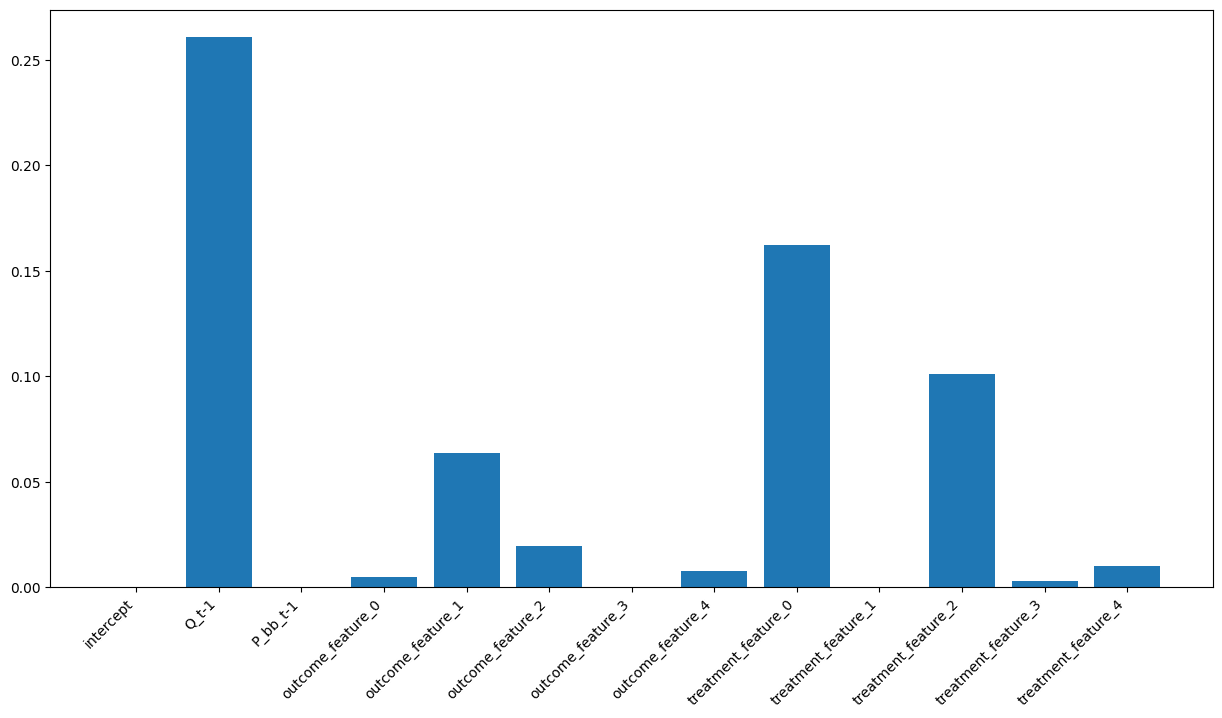

In [148]:
plt.bar(r2_contributions_linear.keys(), r2_contributions_linear.values())
plt.xticks(rotation=45, ha='right')
plt.show()

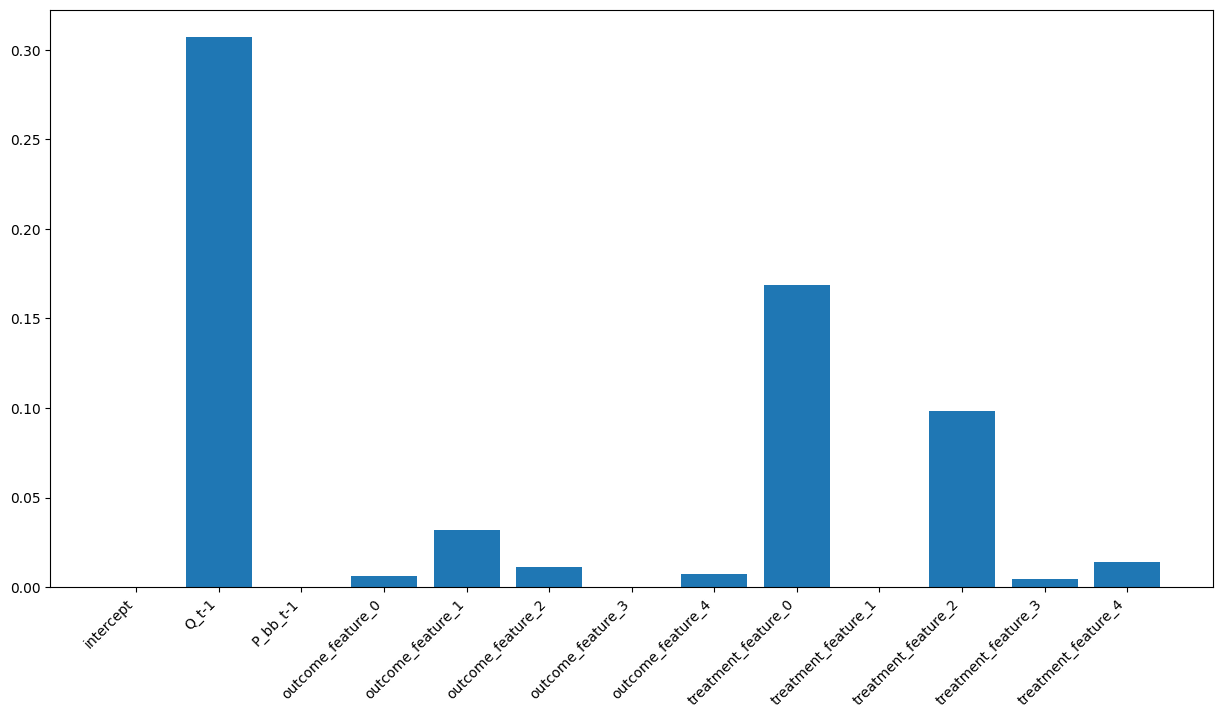

In [149]:
plt.bar(r2_contributions_linear_interactions.keys(), r2_contributions_linear_interactions.values())
plt.xticks(rotation=45, ha='right')
plt.show()

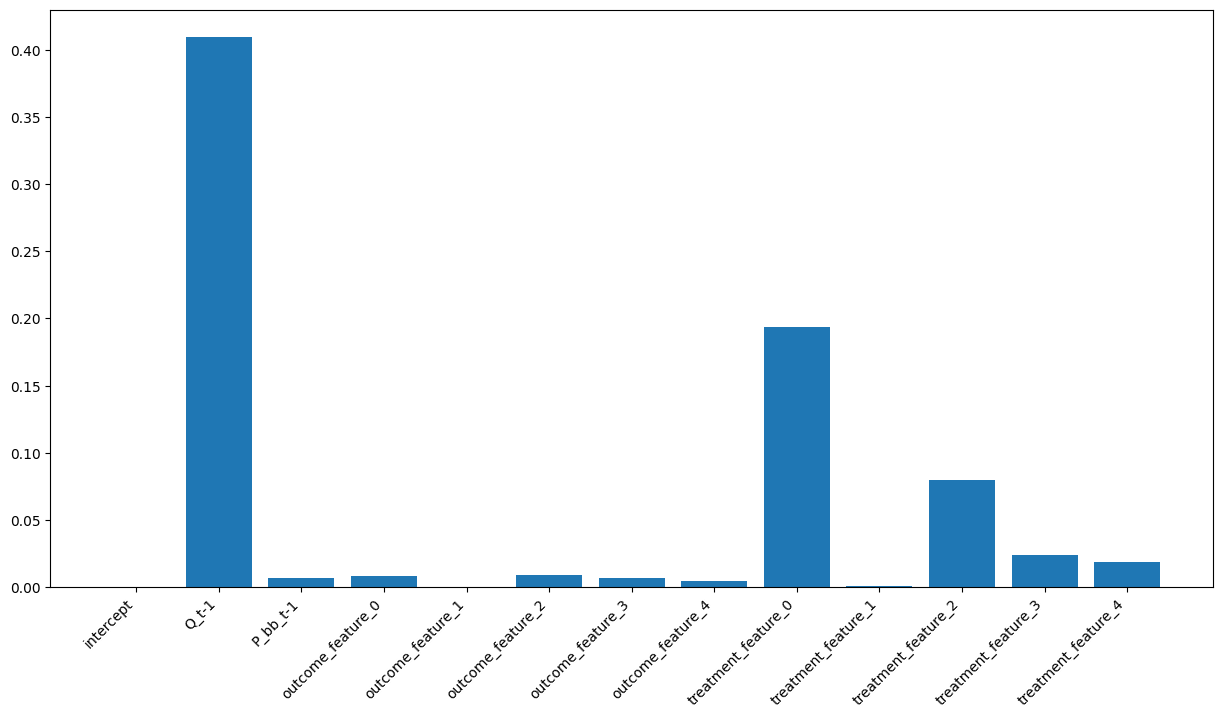

In [150]:
plt.bar(r2_contributions_plr.keys(), r2_contributions_plr.values())
plt.xticks(rotation=45, ha='right')
plt.show()

## $\Chi^2$ Test

In [151]:
controls_similarities

['outcome_feature_0',
 'outcome_feature_1',
 'outcome_feature_2',
 'outcome_feature_3',
 'outcome_feature_4',
 'treatment_feature_0',
 'treatment_feature_1',
 'treatment_feature_2',
 'treatment_feature_3',
 'treatment_feature_4']

In [152]:
df_basis_sorted.columns

Index(['intercept', 'Q_t-1', 'P_bb_t-1', 'outcome_feature_0',
       'outcome_feature_2', 'outcome_feature_4', 'treatment_feature_1'],
      dtype='object')

In [153]:
# select index with cluster similarity 
cluster_treatment_ids = [i for i, variable in enumerate(df_basis.columns) if variable in controls_similarities]
cluster_treatment_ids

[3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

In [154]:
lin_p_val = chi2_test(cate_models_polynomial['Linear Specification'], cluster_treatment_ids)
lin_interactions_p_val = chi2_test(
    cate_models_polynomial['Linear Specification (Interactions)'], cluster_treatment_ids
)
tab_dml_p_val = chi2_test(
    cate_models_polynomial['PLR Specification'], cluster_treatment_ids
)

print(f"Linear Specification p-value: {lin_p_val} (sample size: {len(df_dynamic)})")
print(f"Linear Specification (Interactions) p-value: {lin_interactions_p_val} (sample size: {len(df_dynamic)})")
print(f"PLR Specification p-value: {tab_dml_p_val} (sample size: {len(df_dynamic)})")

Linear Specification p-value: 0.053868759503217345 (sample size: 38041)
Linear Specification (Interactions) p-value: 0.03923508878688042 (sample size: 38041)
PLR Specification p-value: 1.2912615210414202e-07 (sample size: 38041)


In [155]:
het_ids = [1, 2, 3, 4, 5, 6]

lin_p_val = chi2_test(cate_models_polynomial['Linear Specification'], het_ids)
lin_interactions_p_val = chi2_test(
    cate_models_polynomial['Linear Specification (Interactions)'], het_ids
)
tab_dml_p_val = chi2_test(
    cate_models_polynomial['PLR Specification'], het_ids
)

print(f"Linear Specification p-value: {lin_p_val} (sample size: {len(df_dynamic)})")
print(f"Linear Specification (Interactions) p-value: {lin_interactions_p_val} (sample size: {len(df_dynamic)})")
print(f"PLR Specification p-value: {tab_dml_p_val} (sample size: {len(df_dynamic)})")

Linear Specification p-value: 0.01331496668922083 (sample size: 38041)
Linear Specification (Interactions) p-value: 0.009133508306363614 (sample size: 38041)
PLR Specification p-value: 0.0007419067150453706 (sample size: 38041)


## Sorted Effects

In [156]:
treatment_ids = [0, 1, 2] + cluster_treatment_ids
df_basis_sorted = df_basis.iloc[:, treatment_ids]#.join(df_dynamic[["ASIN", "date"]])

In [157]:
df_basis_sorted

,intercept,Q_t-1,P_bb_t-1,outcome_feature_0,outcome_feature_1,outcome_feature_2,outcome_feature_3,outcome_feature_4,treatment_feature_0,treatment_feature_1,treatment_feature_2,treatment_feature_3,treatment_feature_4
0,1.0,0.305280,0.463601,-0.139102,-6.665997e-07,-5.245164e-07,-6.745338e-07,-0.296434,-0.189208,-0.000362,-0.366351,-0.325338,-0.019359
1,1.0,0.272505,0.653600,-0.139102,-6.665997e-07,-5.245164e-07,-6.745338e-07,-0.296434,-0.189208,-0.000362,-0.366351,-0.325338,-0.019359
2,1.0,0.036240,0.687961,-0.139102,-6.665997e-07,-5.245164e-07,-6.745338e-07,-0.296434,-0.189208,-0.000362,-0.366351,-0.325338,-0.019359
3,1.0,0.025283,0.636881,-0.139102,-6.665997e-07,-5.245164e-07,-6.745338e-07,-0.296434,-0.189208,-0.000362,-0.366351,-0.325338,-0.019359
4,1.0,-0.051370,0.556816,-0.139102,-6.665997e-07,-5.245164e-07,-6.745338e-07,-0.296434,-0.189208,-0.000362,-0.366351,-0.325338,-0.019359
...,...,...,...,...,...,...,...,...,...,...,...,...,...
38036,1.0,0.009068,0.478593,-0.099876,-6.665997e-07,-5.245164e-07,-6.745338e-07,-0.224040,0.189206,-0.000705,0.252685,0.362749,-0.045018
38037,1.0,-0.393270,-0.753352,0.366191,-7.265997e-07,-5.245164e-07,-7.345338e-07,0.616771,-0.110141,-0.000514,-0.309156,-0.183238,-0.027103
38038,1.0,-0.277916,-0.753352,0.289805,-7.265997e-07,-5.245164e-07,-7.345338e-07,0.414491,-0.118277,-0.000501,-0.324017,-0.196566,-0.026400
38039,1.0,1.267533,-1.535804,-0.997765,-4.865997e-07,-2.845164e-07,-3.745338e-07,-1.378528,-0.542099,0.003902,-0.932840,-0.638036,0.229731


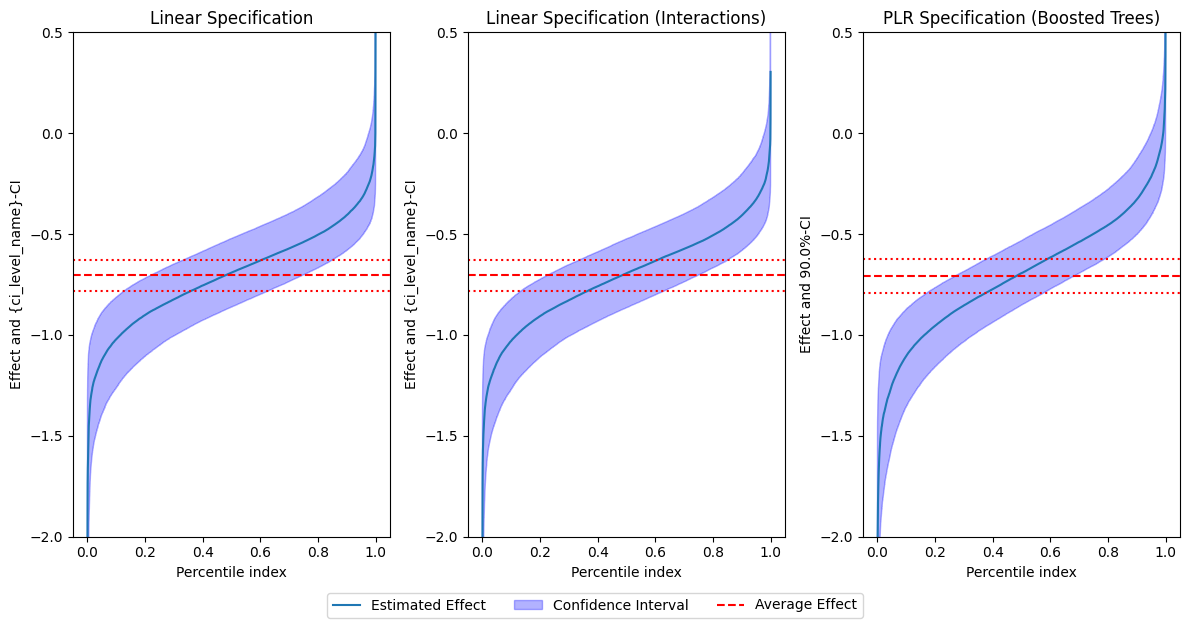

In [158]:
uniform_ci=False

plt.rcParams["figure.figsize"] = (
    15.0,
    7.5,
)  # Adjusted the figure size for side-by-side plots
# Determine the number of models to plot
num_plots = 1
# Create subplots with cate_vars as rows and models as columns
fig, axs = plt.subplots(nrows=num_plots, ncols=3, figsize=(12, 6 * num_plots))
# If there's only one model, axs won't be a list, so wrap it in a list
if num_plots == 1:
    axs = np.array([axs, axs])  # Create a 2-column array


# Linear model
df_lin_ci_pointwise = predict_cate(
    cate_models_polynomial["Linear Specification"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
)
df_lin_ci_pointwise_sorted = df_lin_ci_pointwise.apply(
    lambda x: x.sort_values().values, axis=0
)
df_lin_ci_uniform = predict_cate(
    cate_models_polynomial["Linear Specification"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
    joint=True,
)
df_lin_ci_uniform_sorted = df_lin_ci_uniform.apply(
    lambda x: x.sort_values().values, axis=0
)
lm_intercept = cate_models_polynomial["Linear Specification"].params["intercept"]
lm_intercept_ci = cate_models_polynomial["Linear Specification"].conf_int().loc["intercept"]

# Tabular DML model
df_tab_dml_ci_pointwise = predict_cate(
    cate_models_polynomial["Linear Specification (Interactions)"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
)
df_tab_dml_ci_pointwise_sorted = df_tab_dml_ci_pointwise.apply(
    lambda x: x.sort_values().values, axis=0
)
df_tab_dml_ci_joint = predict_cate(
    cate_models_polynomial["Linear Specification (Interactions)"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
    joint=True,
)
df_tab_dml_ci_joint_sorted = df_tab_dml_ci_joint.apply(
    lambda x: x.sort_values().values, axis=0
)

tab_dml_intercept = cate_models_polynomial["Linear Specification"].params["intercept"]
tab_dml_intercept_ci = cate_models_polynomial["Linear Specification"].conf_int().loc["intercept"]

# PLR Model
df_deep_dml_ci_pointwise = predict_cate(
    cate_models_polynomial['PLR Specification'],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
)
df_deep_dml_ci_pointwise_sorted = df_deep_dml_ci_pointwise.apply(
    lambda x: x.sort_values().values, axis=0
)
df_deep_dml_ci_joint = predict_cate(
    cate_models_polynomial['PLR Specification'],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
    joint=True,
)
df_deep_dml_ci_joint_sorted = df_deep_dml_ci_joint.apply(
    lambda x: x.sort_values().values, axis=0
)
deep_dml_intercept = cate_models_polynomial['PLR Specification'].blp_model.params[
    "intercept"
]
deep_dml_intercept_ci = (
    cate_models_polynomial['PLR Specification'].blp_model.conf_int().loc["intercept"]
)

# Calculate the y-axis limits for this row
y_min = min(
    df_lin_ci_pointwise[ci_names[0]].min(),
    df_lin_ci_uniform[ci_names[0]].min(),
    df_tab_dml_ci_pointwise[ci_names[0]].min(),
    df_tab_dml_ci_joint[ci_names[0]].min(),
    df_deep_dml_ci_pointwise[ci_names[0]].min(),
    df_deep_dml_ci_joint[ci_names[0]].min(),
)
y_max = max(
    df_lin_ci_pointwise[ci_names[1]].max(),
    df_lin_ci_uniform[ci_names[1]].max(),
    df_tab_dml_ci_pointwise[ci_names[1]].max(),
    df_tab_dml_ci_joint[ci_names[1]].max(),
    df_deep_dml_ci_pointwise[ci_names[1]].max(),
    df_deep_dml_ci_joint[ci_names[1]].max(),
)

# further adjust y-axis limits
y_min = max(y_min, -2)
y_max = min(y_max, 0.5)
percentiles_idx = np.linspace(0, 1, df_dynamic.shape[0])
percentiles_idx_full = np.linspace(0, 1, df_dynamic.shape[0])
# Plot on the first column
i = 0
ax0 = axs[i, 0]
ax0.plot(
    percentiles_idx_full, df_lin_ci_pointwise_sorted["effect"], label="Estimated Effect"
)
ax0.fill_between(
    percentiles_idx_full,
    df_lin_ci_pointwise_sorted[ci_names[0]],
    df_lin_ci_pointwise_sorted[ci_names[1]],
    color="b",
    alpha=0.3,
    label="Confidence Interval",
)
if uniform_ci:
    ax0.fill_between(
        percentiles_idx_full,
        df_lin_ci_uniform_sorted[ci_names[0]],
        df_lin_ci_uniform_sorted[ci_names[1]],
        color="b",
        alpha=0.1,
        label="Uniform Confidence Interval",
    )
ax0.axhline(y=lm_intercept, color="r", linestyle="--", label="ATE")
ax0.axhline(y=lm_intercept_ci[0], color="r", linestyle="dotted")
ax0.axhline(y=lm_intercept_ci[1], color="r", linestyle="dotted")
ax0.set_title("Linear Specification")
ax0.set_xlabel("Percentile index")
ax0.set_ylabel("Effect and {ci_level_name}-CI")
ax0.set_ylim(y_min, y_max)
ax1 = axs[i, 1]
ax1.plot(
    percentiles_idx_full,
    df_tab_dml_ci_pointwise_sorted["effect"],
    label="Estimated Effect",
)
ax1.fill_between(
    percentiles_idx_full,
    df_tab_dml_ci_pointwise_sorted[ci_names[0]],
    df_tab_dml_ci_pointwise_sorted[ci_names[1]],
    color="b",
    alpha=0.3,
    label="Confidence Interval",
)
if uniform_ci:
    ax1.fill_between(
        percentiles_idx_full,
        df_tab_dml_ci_joint_sorted[ci_names[0]],
        df_tab_dml_ci_joint_sorted[ci_names[1]],
        color="b",
        alpha=0.1,
        label="Uniform Confidence Interval",
    )
ax1.axhline(y=tab_dml_intercept, color="r", linestyle="--", label="Average Effect")
ax1.axhline(y=tab_dml_intercept_ci[0], color="r", linestyle="dotted")
ax1.axhline(y=tab_dml_intercept_ci[1], color="r", linestyle="dotted")
ax1.set_title("Linear Specification (Interactions)")
ax1.set_xlabel("Percentile index")
ax1.set_ylabel("Effect and {ci_level_name}-CI")
ax1.set_ylim(y_min, y_max)

ax2 = axs[i, 2]
ax2.plot(
    percentiles_idx_full,
    df_deep_dml_ci_pointwise_sorted["effect"],
    label="Estimated Effect",
)
ax2.fill_between(
    percentiles_idx_full,
    df_deep_dml_ci_pointwise_sorted[ci_names[0]],
    df_deep_dml_ci_pointwise_sorted[ci_names[1]],
    color="b",
    alpha=0.3,
    label="Confidence Interval",
)
if uniform_ci:
    ax2.fill_between(
        percentiles_idx_full,
        df_deep_dml_ci_joint_sorted[ci_names[0]],
        df_deep_dml_ci_joint_sorted[ci_names[1]],
        color="b",
        alpha=0.1,
        label="Uniform Confidence Interval",
    )
ax2.axhline(y=deep_dml_intercept, color="r", linestyle="--", label="Average Effect")
ax2.axhline(y=deep_dml_intercept_ci[0], color="r", linestyle="dotted")
ax2.axhline(y=deep_dml_intercept_ci[1], color="r", linestyle="dotted")

ax2.set_title("PLR Specification (Boosted Trees)")
ax2.set_xlabel("Percentile index")
ax2.set_ylabel(f"Effect and {ci_level_name}-CI")
ax2.set_ylim(y_min, y_max)

# Create a single legend for all plots and place it at the lower center
handles, labels = axs[
    -1, 1
].get_legend_handles_labels()  # Collect handles and labels from the last subplot
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=4)
# Adjust layout to make space for the legend
plt.tight_layout(rect=[0, 0.0, 1, 1])  # Leave space at the bottom for the legend

# Save the figure with tight bounding box to include the legend
plt.savefig(
    os.path.join(output_dir, "cluster_sorted_effects.png"), 
    bbox_inches="tight"
)
plt.show()

In [159]:
quantiles = np.arange(start=0.01, stop=1, step=0.01)
m = len(quantiles)
pes = df_tab_dml_ci_pointwise["effect"]
spes = df_tab_dml_ci_pointwise["effect"].quantile(quantiles).values
spes

array([-1.34730314, -1.25791117, -1.21061095, -1.17105492, -1.13701942,
       -1.10802291, -1.08443751, -1.06447893, -1.04684581, -1.02926981,
       -1.01338952, -0.99878006, -0.98499995, -0.97168164, -0.95933425,
       -0.94777055, -0.93709907, -0.92614417, -0.91671626, -0.90653367,
       -0.89755619, -0.88840876, -0.88031477, -0.87257303, -0.86514465,
       -0.85707001, -0.84931031, -0.84218553, -0.83548376, -0.82796498,
       -0.82091206, -0.81355681, -0.80617684, -0.79960181, -0.79213769,
       -0.7853505 , -0.77841695, -0.77167575, -0.76500106, -0.75880677,
       -0.75223149, -0.74611883, -0.73937936, -0.73295956, -0.72627472,
       -0.71993831, -0.71341969, -0.70745689, -0.70054452, -0.69443192,
       -0.68801212, -0.6814148 , -0.67556182, -0.6696375 , -0.66372996,
       -0.65802109, -0.65189422, -0.64574082, -0.63934898, -0.63302266,
       -0.62682289, -0.62050276, -0.61440986, -0.60837732, -0.6026325 ,
       -0.59699269, -0.59113882, -0.58566669, -0.57945871, -0.57

In [160]:
from scipy.stats import norm

alpha = 0.1
Y_tilde, D_tilde = plr_obj._partial_out()
n = len(df_dynamic)
B = 500
rng = np.random.default_rng(42)

spes_mat = np.full((m, B), fill_value=np.nan)

for b in range(B):
    sample_indices = rng.choice(n, size=n, replace=True)
    Y_b = Y_tilde[sample_indices]
    D_b = D_tilde[sample_indices]
    psi_D_b = df_basis.values * D_b.reshape(-1, 1)
    model_b = sm.OLS(Y_b, psi_D_b).fit()
    beta_b = model_b.params
    pes_b = beta_b.T @ df_basis.values.T
    spes_mat[:, b] = np.quantile(pes_b, quantiles)


Z_mat = np.sqrt(n) * (spes_mat - spes.reshape(-1, 1))
iqr_norm = norm.ppf(0.75) - norm.ppf(0.25)
iqr_emp = np.quantile(Z_mat, 0.75, axis=1) - np.quantile(Z_mat, 0.25, axis=1)
Sigma_u = iqr_emp / iqr_norm

t = np.max((np.abs(Z_mat) / Sigma_u.reshape(-1, 1)), axis=0)
t_quant = np.quantile(t, 1 - alpha)

spes_boot_cis = pd.DataFrame({
    "quantiles": quantiles,
    "lower": spes - (t_quant / np.sqrt(n)) * Sigma_u,
    "effect": spes,
    "upper": spes + (t_quant / np.sqrt(n)) * Sigma_u
    }
)
spes_boot_cis

,quantiles,lower,effect,upper
0,0.01,-1.937843,-1.347303,-0.756763
1,0.02,-1.729169,-1.257911,-0.786653
2,0.03,-1.626169,-1.210611,-0.795053
3,0.04,-1.567310,-1.171055,-0.774800
4,0.05,-1.516038,-1.137019,-0.758001
...,...,...,...,...
94,0.95,-0.658686,-0.327898,0.002891
95,0.96,-0.646884,-0.303686,0.039512
96,0.97,-0.652528,-0.275697,0.101133
97,0.98,-0.687535,-0.242782,0.201971


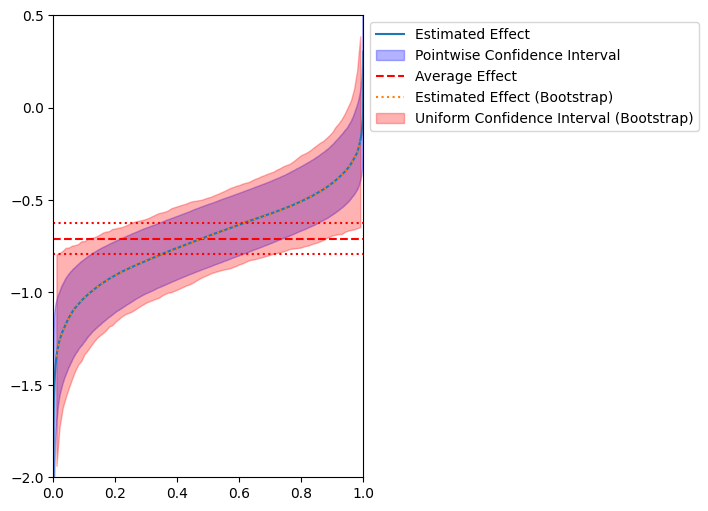

In [161]:
plt.figure(figsize=(4, 6))

plt.plot(
    percentiles_idx_full,
    df_tab_dml_ci_joint_sorted["effect"],
    label="Estimated Effect",
)
plt.fill_between(
    percentiles_idx_full,
    df_tab_dml_ci_pointwise_sorted[ci_names[0]],
    df_tab_dml_ci_pointwise_sorted[ci_names[1]],
    color="b",
    alpha=0.3,
    label="Pointwise Confidence Interval",
)
if uniform_ci:
    plt.fill_between(
        percentiles_idx_full,
        df_tab_dml_ci_joint_sorted[ci_names[0]],
        df_tab_dml_ci_joint_sorted[ci_names[1]],
        color="b",
        alpha=0.1,
        label="Uniform Confidence Interval",
    )
plt.axhline(y=deep_dml_intercept, color="r", linestyle="--", label="Average Effect")
plt.axhline(y=deep_dml_intercept_ci[0], color="r", linestyle="dotted")
plt.axhline(y=deep_dml_intercept_ci[1], color="r", linestyle="dotted")

plt.plot(
    spes_boot_cis["quantiles"], spes_boot_cis["effect"], label="Estimated Effect (Bootstrap)", linestyle="dotted"
)
plt.fill_between(
    spes_boot_cis["quantiles"].sort_values(),
    spes_boot_cis["lower"].sort_values(),
    spes_boot_cis["upper"].sort_values(),
    color="red",
    alpha=0.3,
    label="Uniform Confidence Interval (Bootstrap)",
)

plt.xlim(0, 1)
plt.legend(loc="best", bbox_to_anchor=(1, 1))
plt.ylim(-2, 0.5)
#plt.axhline(y=deep_dml_intercept, color="r", linestyle="--", label="ATE")
plt.show()

In [162]:
alpha = 0.1
# Assuming the partial out function returns (Y_tilde, D_tilde)
Y_tilde, D_tilde = plr_obj._partial_out()
n = len(df_dynamic)

# Define bootstrap parameters and quantile levels
B = 1000
rng = np.random.default_rng(42)
quantiles = np.arange(start=0.2, stop=0.81, step=0.01)
m = len(quantiles)

# Compute the original quantile estimates (spes) from your base model
# (This assumes you have a way to get the original model predictions)
original_model = sm.OLS(Y_tilde, D_tilde).fit()
pes_original = original_model.predict(D_tilde)
spes = np.quantile(pes_original, quantiles)

spes_mat = np.full((m, B), fill_value=np.nan)

for b in range(B):
    sample_indices = rng.choice(n, size=n, replace=True)
    Y_b = Y_tilde[sample_indices]
    D_b = D_tilde[sample_indices]
    model_b = sm.OLS(Y_b, D_b).fit()
    pes_b = model_b.predict(D_tilde)
    spes_mat[:, b] = np.quantile(pes_b, quantiles)

Z_mat = np.sqrt(n) * (spes_mat - spes.reshape(-1, 1))
iqr_norm = norm.ppf(0.75) - norm.ppf(0.25)
iqr_emp = np.quantile(Z_mat, 0.75, axis=1) - np.quantile(Z_mat, 0.25, axis=1)
Sigma_u = iqr_emp / iqr_norm

# Compute t statistics for each bootstrap replication
t = np.max(np.abs(Z_mat) / Sigma_u.reshape(-1, 1), axis=0)
t_quant = np.quantile(t, 1 - alpha)

spes_boot_cis = pd.DataFrame({
    "lower": spes - (t_quant / np.sqrt(n)) * Sigma_u,
    "effect": spes,
    "upper": spes + (t_quant / np.sqrt(n)) * Sigma_u
})
spes_boot_cis

,lower,effect,upper
0,-0.032574,-0.030317,-0.028060
1,-0.030672,-0.028547,-0.026422
2,-0.028805,-0.026810,-0.024814
3,-0.027174,-0.025292,-0.023409
4,-0.025518,-0.023750,-0.021982
...,...,...,...
57,0.021654,0.023396,0.025137
58,0.023119,0.024978,0.026838
59,0.024692,0.026678,0.028664
60,0.026323,0.028439,0.030556


In [163]:
df_effects = df_dynamic[["ASIN", "date"]].copy() 

df_effects["SortEff_lin"] = df_lin_ci_pointwise["effect"]
df_effects["SortEff_tab_dml"] = df_tab_dml_ci_pointwise["effect"]
df_effects["SortEff_deep_dml"] = df_deep_dml_ci_pointwise["effect"]

df_effects.to_csv(os.path.join(output_dir, "sorted_effects.csv"), index=False)

## Heterogeneity on PCA Components

In [164]:
eigenRes = np.linalg.eig(df_full_val[[f"emb_{i}" for i in range(256)]].cov())

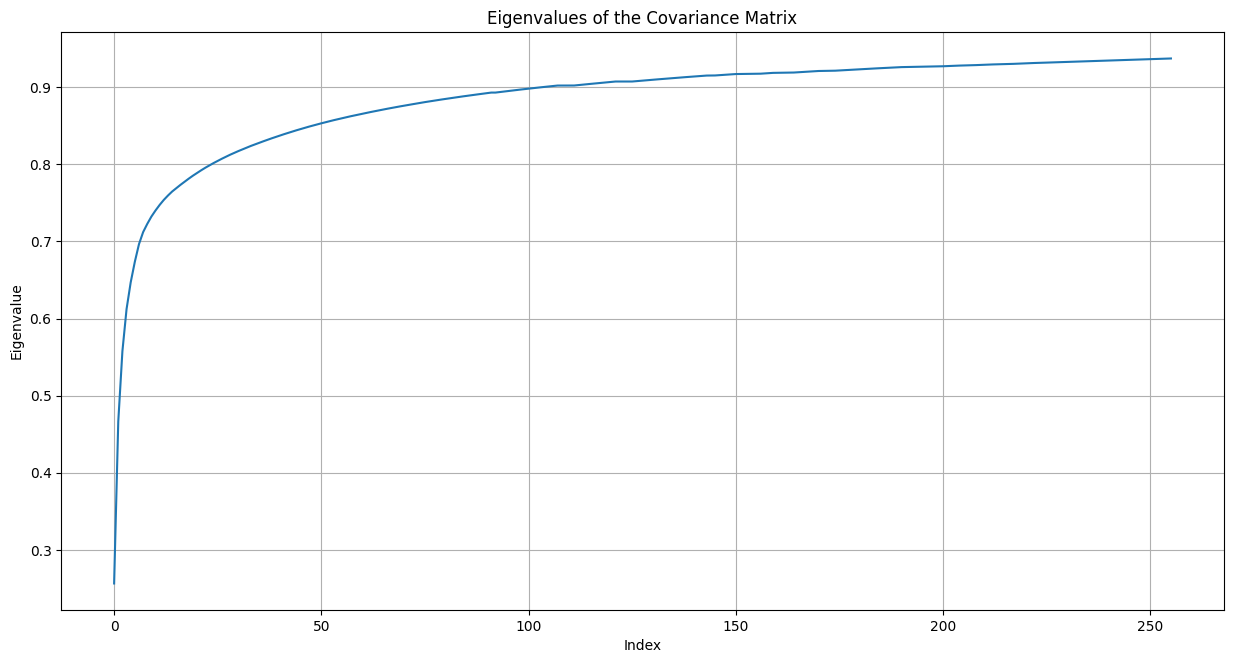

In [165]:
plt.plot(np.cumsum(eigenRes.eigenvalues), label="Cumulative Sum of Eigenvalues")
plt.title("Eigenvalues of the Covariance Matrix")
plt.xlabel("Index")
#plt.xscale("log")
plt.ylabel("Eigenvalue")
plt.grid()
plt.show()

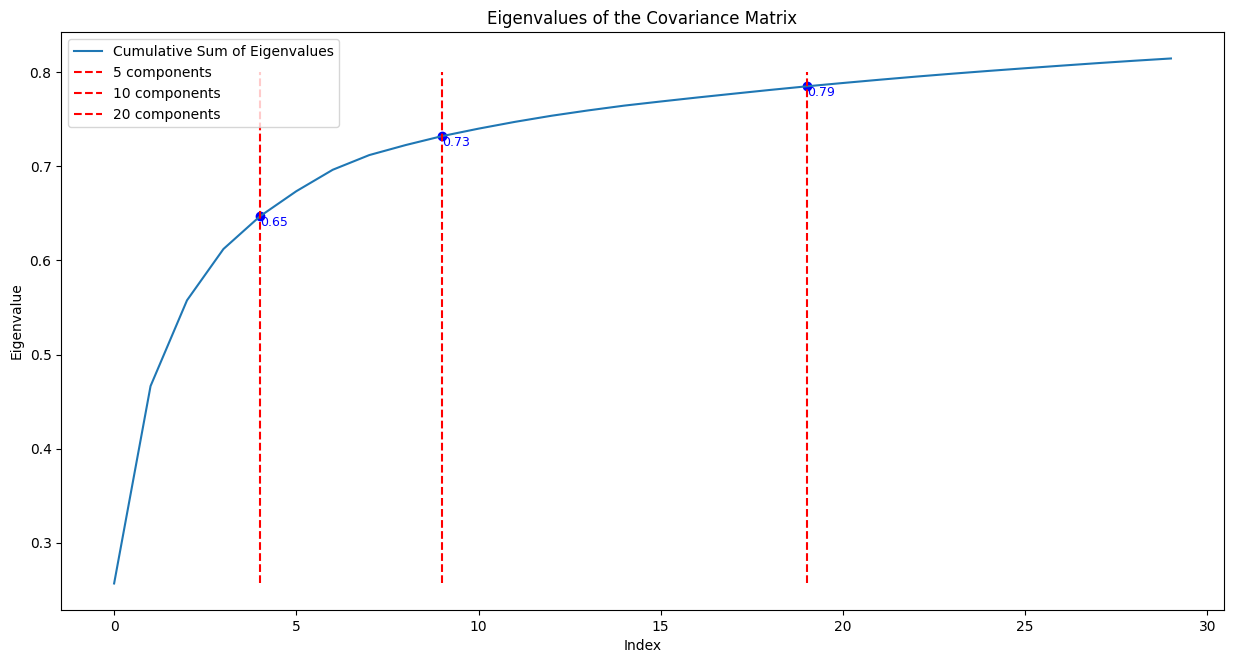

In [166]:
max_eig = 30

# Calculate cumulative sum of eigenvalues
cumsum_eigenvalues = np.cumsum(eigenRes.eigenvalues[:max_eig])

# Plot the cumulative sum of eigenvalues
plt.plot(cumsum_eigenvalues, label="Cumulative Sum of Eigenvalues")
plt.title("Eigenvalues of the Covariance Matrix")
plt.xlabel("Index")
plt.ylabel("Eigenvalue")

# Mark vertical lines and annotate intersection points
components = [5, 10, 20]
for comp in components:
    y_value = cumsum_eigenvalues[comp-1]  # Get the y-axis value at the component index
    plt.vlines(x=comp-1, ymin=cumsum_eigenvalues[0], ymax=0.8, color='r', linestyle='--', label=f'{comp} components')
    plt.scatter(comp-1, y_value, color='blue')  # Mark the intersection point
    plt.text(comp-1 + 0.01, y_value - 0.01, f"{y_value:.2f}", color='blue', fontsize=9)  # Annotate the point

plt.legend()
plt.show()

In [167]:
print(len(df_full_val))

38041


In [168]:
from sklearn.decomposition import PCA

pca_05 = PCA(n_components=5, random_state=42)
pca_10 = PCA(n_components=10, random_state=42)
pca_20 = PCA(n_components=20, random_state=42)

pca_05_results = pca_05.fit_transform(df_full_val[[f"emb_{i}" for i in range(256)]])
pca_10_results = pca_10.fit_transform(df_full_val[[f"emb_{i}" for i in range(256)]])
pca_20_results = pca_20.fit_transform(df_full_val[[f"emb_{i}" for i in range(256)]])
pca_05_results.shape, pca_10_results.shape, pca_20_results.shape

((38041, 5), (38041, 10), (38041, 20))

In [169]:
pca_05_vars = [f"pca_05_{i}" for i in range(5)]
pca_10_vars = [f"pca_10_{i}" for i in range(10)]
pca_20_vars = [f"pca_20_{i}" for i in range(20)]

df_val_pca_05 = pd.DataFrame(pca_05_results, columns=pca_05_vars)
df_val_pca_10 = pd.DataFrame(pca_10_results, columns=pca_10_vars)
df_val_pca_20 = pd.DataFrame(pca_20_results, columns=pca_20_vars)
df_val_pca = pd.concat([df_full_val.reset_index(), df_val_pca_05, df_val_pca_10, df_val_pca_20], axis=1)

df_val_pca.shape

(38041, 400)

In [170]:
n_pcas = ["5", "10", "20"]
df_dynamic = df_val_pca.copy()

cate_kwargs_val = {
    f"pca_{n}_components": {
        'cov_type': 'cluster',
        'cov_kwds': {'groups': df_dynamic["ASIN"]}
    }
    for n in n_pcas
}

cate_models_polynomial = {
    f"pca_{n}_components": {
        'Linear Specification': None,
        'Linear Specification (Interactions)': None,
        'PLR Specification': None,}
        for n in n_pcas
}

for pca_conf, pca_vars in zip(n_pcas, [pca_05_vars, pca_10_vars, pca_20_vars]):
    
    basis_vars = pca_vars + lag_1_vars
    df_basis, column_transformer, column_dict = generate_basis(
        df=df_dynamic,
        cols_without_scaling=pca_vars,
        cols_to_scale=lag_1_vars,
        degree=1
    )
    df_interact_val, interaction_vars = generate_interactions(
    df=df_dynamic,
    df_basis=df_basis,
    cols_to_interact=lag_1_vars)

    cate_controls = lag_1_vars + embeddings + additional_controls
    cate_controls_interactions = cate_controls + interaction_vars

    plr_obj = tab_dml_obj_embeddings_add_controls

    # Linear Models
    cate_models_polynomial[f"pca_{pca_conf}_components"]['Linear Specification'] = lin_model_cate(
        df=df_dynamic,
        outcome=outcome,
        basis=df_basis,
        treatment=base_treatment,
        controls=cate_controls,
        **cate_kwargs_val,
    )

    print(f"\nLinear Specification")
    df_specification_1 = summarize_lin_model(cate_models_polynomial[f"pca_{pca_conf}_components"]['Linear Specification'], level=confidence_level)
    print("=" * 80)#

    cate_models_polynomial[f"pca_{pca_conf}_components"]['Linear Specification (Interactions)'] = lin_model_cate(
        df=df_interact_val,
        outcome=outcome,
        basis=df_basis,
        treatment=base_treatment,
        controls=cate_controls_interactions,
        **cate_kwargs_val,
    )

    print(f"\nLinear specification with interactions")
    df_specification_2 = summarize_lin_model(cate_models_polynomial[f"pca_{pca_conf}_components"]['Linear Specification (Interactions)'], level=confidence_level)
    print("=" * 80)

    # tabular DML model
    cate_models_polynomial[f"pca_{pca_conf}_components"]['PLR Specification'] = plr_obj.cate(
        df_basis, **cate_kwargs_val
    )

    print(f"\nTabular DML PLR Specification")
    df_specification_3 = summarize_lin_model(
        cate_models_polynomial[f"pca_{pca_conf}_components"]['PLR Specification'].blp_model, level=confidence_level
    )
    print("=" * 80)



Linear Specification
            coef  std err       t  P>|t|   5.0%  95.0%
intercept -0.705    0.035 -19.924  0.000 -0.763 -0.646
Q_t-1     -0.179    0.050  -3.573  0.000 -0.261 -0.096
P_bb_t-1  -0.003    0.048  -0.065  0.949 -0.083  0.076
pca_05_0  -0.048    0.095  -0.509  0.611 -0.205  0.108
pca_05_1  -0.015    0.107  -0.137  0.891 -0.191  0.162
pca_05_2   0.057    0.132   0.429  0.668 -0.160  0.273
pca_05_3  -0.325    0.134  -2.430  0.015 -0.546 -0.105
pca_05_4   0.120    0.185   0.651  0.515 -0.184  0.425

Linear specification with interactions
            coef  std err       t  P>|t|   5.0%  95.0%
intercept -0.714    0.035 -20.168  0.000 -0.772 -0.656
Q_t-1     -0.189    0.050  -3.797  0.000 -0.271 -0.107
P_bb_t-1  -0.007    0.049  -0.142  0.887 -0.088  0.074
pca_05_0  -0.034    0.095  -0.360  0.719 -0.191  0.123
pca_05_1  -0.023    0.107  -0.212  0.832 -0.198  0.153
pca_05_2   0.030    0.132   0.229  0.819 -0.187  0.248
pca_05_3  -0.330    0.135  -2.445  0.015 -0.552 -0.108
pca

In [171]:
cate_summary_dfs_pca = {f"pca_{n}_components": [] for n in n_pcas}
summary_list = []

for pca_conf in n_pcas:
    summary_list = []
    for model_name, model in cate_models_polynomial[f"pca_{pca_conf}_components"].items():
        if "Linear" in model_name:
            tmp_summary = summarize_lin_model(model, level=confidence_level)
        else:
            tmp_summary = summarize_lin_model(model.blp_model, level=confidence_level)
        for index, row in tmp_summary.iterrows():
            variable = index
            summary_list.append(
                {
                    "model": model_name,
                    "variable": variable,
                    "coef": row["coef"],
                    "Std.Err.": row["std err"],
                    "lower": row[ci_names[0]],  # Adjusted to match the column name
                    "upper": row[ci_names[1]],  # Adjusted to match the column name
                }
            )

    cate_summary_dfs_pca[f"pca_{pca_conf}_components"] = pd.DataFrame(summary_list)

            coef  std err       t  P>|t|   5.0%  95.0%
intercept -0.705    0.035 -19.924  0.000 -0.763 -0.646
Q_t-1     -0.179    0.050  -3.573  0.000 -0.261 -0.096
P_bb_t-1  -0.003    0.048  -0.065  0.949 -0.083  0.076
pca_05_0  -0.048    0.095  -0.509  0.611 -0.205  0.108
pca_05_1  -0.015    0.107  -0.137  0.891 -0.191  0.162
pca_05_2   0.057    0.132   0.429  0.668 -0.160  0.273
pca_05_3  -0.325    0.134  -2.430  0.015 -0.546 -0.105
pca_05_4   0.120    0.185   0.651  0.515 -0.184  0.425
            coef  std err       t  P>|t|   5.0%  95.0%
intercept -0.714    0.035 -20.168  0.000 -0.772 -0.656
Q_t-1     -0.189    0.050  -3.797  0.000 -0.271 -0.107
P_bb_t-1  -0.007    0.049  -0.142  0.887 -0.088  0.074
pca_05_0  -0.034    0.095  -0.360  0.719 -0.191  0.123
pca_05_1  -0.023    0.107  -0.212  0.832 -0.198  0.153
pca_05_2   0.030    0.132   0.229  0.819 -0.187  0.248
pca_05_3  -0.330    0.135  -2.445  0.015 -0.552 -0.108
pca_05_4   0.144    0.185   0.778  0.437 -0.161  0.449
          

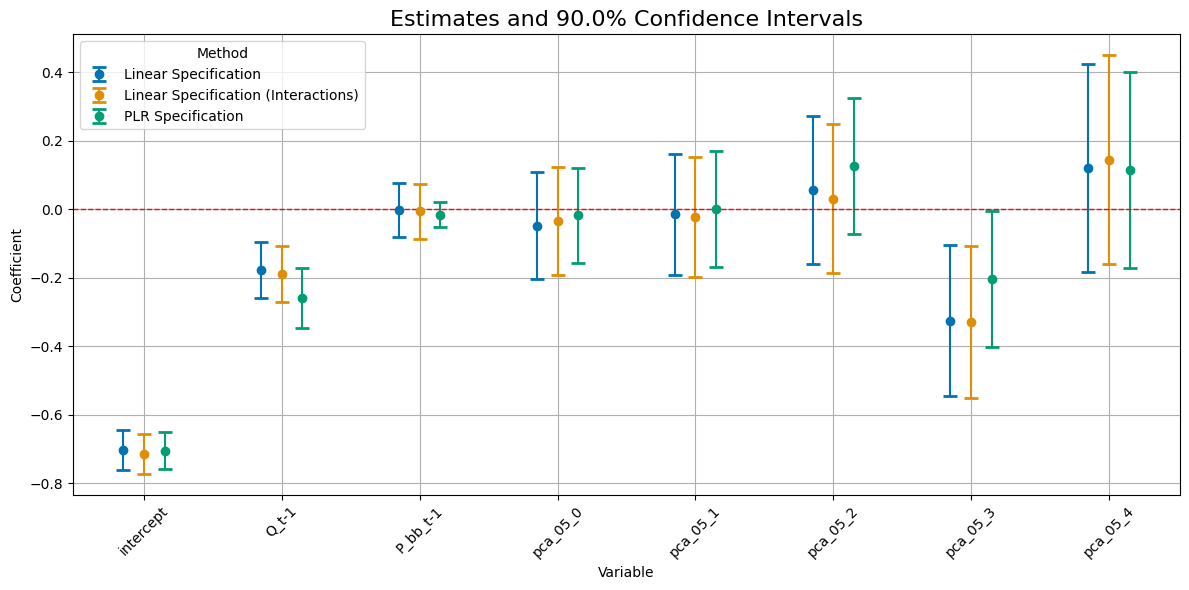

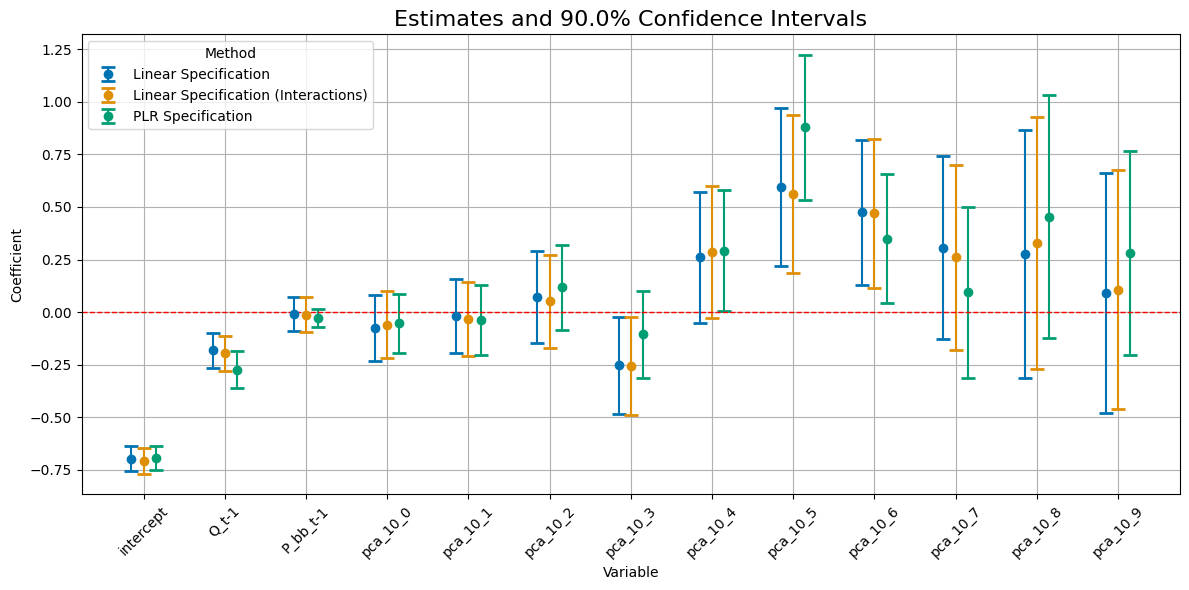

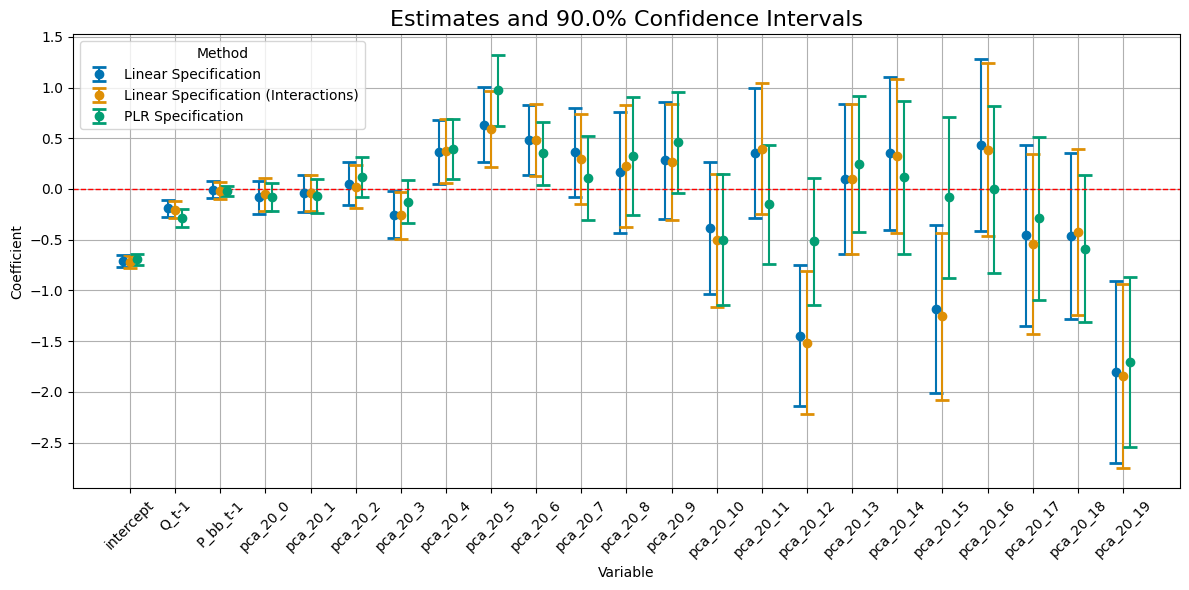

In [172]:
for cate_summary_df in cate_summary_dfs_pca.values():
    models = cate_summary_df["model"].unique()
    variables = cate_summary_df["variable"].unique()
    plt.figure(figsize=(12, 6))
    bar_width = 0.15
    x_positions = np.arange(len(variables))
    for i, model in enumerate(models):
        df_model = cate_summary_df[cate_summary_df["model"] == model]
        if not df_model.empty:
            plt.errorbar(
                x_positions + i * bar_width,
                df_model["coef"],
                yerr=[
                    df_model["coef"] - df_model["lower"],
                    df_model["upper"] - df_model["coef"],
                ],
                fmt="o",
                label=model,
                capsize=5,
                capthick=2,
                ecolor=palette[i % len(palette)],
                color=palette[i % len(palette)],
                zorder=2,
            )
    plt.xticks(x_positions + (len(models) - 1) * bar_width / 2, variables, rotation=45)
    plt.axhline(0, color="red", linestyle="--", linewidth=1)
    plt.title(f"Estimates and {ci_level_name} Confidence Intervals", fontsize=16)
    plt.xlabel("Variable")
    plt.ylabel("Coefficient")
    plt.legend(title="Method")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"pca_and_level_cate_estimates.png"))
    plt.show()

In [173]:
def plot_sorted_func(cate_models_polynomial, pca_vars):
    basis_vars = pca_vars + lag_1_vars
    df_basis, _, _ = generate_basis(
        df=df_dynamic,
        cols_without_scaling=pca_vars,
        cols_to_scale=lag_1_vars,
        degree=1
    )
    cluster_treatment_ids = [i for i, variable in enumerate(df_basis.columns) if variable in pca_vars]
    treatment_ids = [0, 1, 2] + cluster_treatment_ids
    df_basis_sorted = df_basis.iloc[:, treatment_ids]
    plt.rcParams["figure.figsize"] = (
        15.0,
        7.5,
    )  # Adjusted the figure size for side-by-side plots
    # Determine the number of models to plot
    num_plots = 1
    # Create subplots with cate_vars as rows and models as columns
    fig, axs = plt.subplots(nrows=num_plots, ncols=3, figsize=(12, 6 * num_plots))
    # If there's only one model, axs won't be a list, so wrap it in a list
    if num_plots == 1:
        axs = np.array([axs, axs])  # Create a 2-column array


    # Linear model
    df_lin_ci_pointwise = predict_cate(
        cate_models_polynomial["Linear Specification"],
        df_basis_sorted,
        treatment_ids=treatment_ids,
        level=confidence_level,
    )
    df_lin_ci_pointwise_sorted = df_lin_ci_pointwise.apply(
        lambda x: x.sort_values().values, axis=0
    )
    df_lin_ci_uniform = predict_cate(
        cate_models_polynomial["Linear Specification"],
        df_basis_sorted,
        treatment_ids=treatment_ids,
        level=confidence_level,
        joint=True,
    )
    df_lin_ci_uniform_sorted = df_lin_ci_uniform.apply(
        lambda x: x.sort_values().values, axis=0
    )
    lm_intercept = cate_models_polynomial["Linear Specification"].params["intercept"]
    lm_intercept_ci = cate_models_polynomial["Linear Specification"].conf_int().loc["intercept"]

    # Tabular DML model
    df_tab_dml_ci_pointwise = predict_cate(
        cate_models_polynomial["Linear Specification (Interactions)"],
        df_basis_sorted,
        treatment_ids=treatment_ids,
        level=confidence_level,
    )
    df_tab_dml_ci_pointwise_sorted = df_tab_dml_ci_pointwise.apply(
        lambda x: x.sort_values().values, axis=0
    )
    df_tab_dml_ci_joint = predict_cate(
        cate_models_polynomial["Linear Specification (Interactions)"],
        df_basis_sorted,
        treatment_ids=treatment_ids,
        level=confidence_level,
        joint=True,
    )
    df_tab_dml_ci_joint_sorted = df_tab_dml_ci_joint.apply(
        lambda x: x.sort_values().values, axis=0
    )

    tab_dml_intercept = cate_models_polynomial["Linear Specification"].params["intercept"]
    tab_dml_intercept_ci = cate_models_polynomial["Linear Specification"].conf_int().loc["intercept"]

    # PLR Model
    df_deep_dml_ci_pointwise = predict_cate(
        cate_models_polynomial['PLR Specification'],
        df_basis_sorted,
        treatment_ids=treatment_ids,
        level=confidence_level,
    )
    df_deep_dml_ci_pointwise_sorted = df_deep_dml_ci_pointwise.apply(
        lambda x: x.sort_values().values, axis=0
    )
    df_deep_dml_ci_joint = predict_cate(
        cate_models_polynomial['PLR Specification'],
        df_basis_sorted,
        treatment_ids=treatment_ids,
        level=confidence_level,
        joint=True,
    )
    df_deep_dml_ci_joint_sorted = df_deep_dml_ci_joint.apply(
        lambda x: x.sort_values().values, axis=0
    )
    deep_dml_intercept = cate_models_polynomial['PLR Specification'].blp_model.params[
        "intercept"
    ]
    deep_dml_intercept_ci = (
        cate_models_polynomial['PLR Specification'].blp_model.conf_int().loc["intercept"]
    )

    # Calculate the y-axis limits for this row
    y_min = min(
        df_lin_ci_pointwise[ci_names[0]].min(),
        df_lin_ci_uniform[ci_names[0]].min(),
        df_tab_dml_ci_pointwise[ci_names[0]].min(),
        df_tab_dml_ci_joint[ci_names[0]].min(),
        df_deep_dml_ci_pointwise[ci_names[0]].min(),
        df_deep_dml_ci_joint[ci_names[0]].min(),
    )
    y_max = max(
        df_lin_ci_pointwise[ci_names[1]].max(),
        df_lin_ci_uniform[ci_names[1]].max(),
        df_tab_dml_ci_pointwise[ci_names[1]].max(),
        df_tab_dml_ci_joint[ci_names[1]].max(),
        df_deep_dml_ci_pointwise[ci_names[1]].max(),
        df_deep_dml_ci_joint[ci_names[1]].max(),
    )

    # further adjust y-axis limits
    y_min = max(y_min, -1.75)
    y_max = min(y_max, 0.0)
    percentiles_idx = np.linspace(0, 1, df_dynamic.shape[0])
    percentiles_idx_full = np.linspace(0, 1, df_dynamic.shape[0])
    # Plot on the first column
    i = 0
    ax0 = axs[i, 0]
    ax0.plot(
        percentiles_idx_full, df_lin_ci_pointwise_sorted["effect"], label="Estimated Effect"
    )
    ax0.fill_between(
        percentiles_idx_full,
        df_lin_ci_pointwise_sorted[ci_names[0]],
        df_lin_ci_pointwise_sorted[ci_names[1]],
        color="b",
        alpha=0.3,
        label="Confidence Interval",
    )
    if uniform_ci:
        ax0.fill_between(
            percentiles_idx_full,
            df_lin_ci_uniform_sorted[ci_names[0]],
            df_lin_ci_uniform_sorted[ci_names[1]],
            color="b",
            alpha=0.1,
            label="Uniform Confidence Interval",
        )
    ax0.axhline(y=lm_intercept, color="r", linestyle="--", label="ATE")
    ax0.axhline(y=lm_intercept_ci[0], color="r", linestyle="dotted")
    ax0.axhline(y=lm_intercept_ci[1], color="r", linestyle="dotted")
    ax0.set_title(f"Linear Specification")
    ax0.set_xlabel("Percentile index")
    ax0.set_ylabel(f"Effect and {ci_level_name}-CI")
    ax0.set_ylim(y_min, y_max)
    ax1 = axs[i, 1]
    ax1.plot(
        percentiles_idx_full,
        df_tab_dml_ci_pointwise_sorted["effect"],
        label="Estimated Effect",
    )
    ax1.fill_between(
        percentiles_idx_full,
        df_tab_dml_ci_pointwise_sorted[ci_names[0]],
        df_tab_dml_ci_pointwise_sorted[ci_names[1]],
        color="b",
        alpha=0.3,
        label="Confidence Interval",
    )
    if uniform_ci:
        ax1.fill_between(
            percentiles_idx_full,
            df_tab_dml_ci_joint_sorted[ci_names[0]],
            df_tab_dml_ci_joint_sorted[ci_names[1]],
            color="b",
            alpha=0.1,
            label="Uniform Confidence Interval",
        )
    ax1.axhline(y=tab_dml_intercept, color="r", linestyle="--", label="Average Effect")
    ax1.axhline(y=tab_dml_intercept_ci[0], color="r", linestyle="dotted")
    ax1.axhline(y=tab_dml_intercept_ci[1], color="r", linestyle="dotted")
    ax1.set_title(f"Linear Specification (Interactions)")
    ax1.set_xlabel("Percentile index")
    ax1.set_ylabel(f"Effect and {ci_level_name}-CI")
    ax1.set_ylim(y_min, y_max)

    ax2 = axs[i, 2]
    ax2.plot(
        percentiles_idx_full,
        df_deep_dml_ci_pointwise_sorted["effect"],
        label="Estimated Effect",
    )
    ax2.fill_between(
        percentiles_idx_full,
        df_deep_dml_ci_pointwise_sorted[ci_names[0]],
        df_deep_dml_ci_pointwise_sorted[ci_names[1]],
        color="b",
        alpha=0.3,
        label="Confidence Interval",
    )
    if uniform_ci:
        ax2.fill_between(
            percentiles_idx_full,
            df_deep_dml_ci_joint_sorted[ci_names[0]],
            df_deep_dml_ci_joint_sorted[ci_names[1]],
            color="b",
            alpha=0.1,
            label="Uniform Confidence Interval",
        )
    ax2.axhline(y=deep_dml_intercept, color="r", linestyle="--", label="Average Effect")
    ax2.axhline(y=deep_dml_intercept_ci[0], color="r", linestyle="dotted")
    ax2.axhline(y=deep_dml_intercept_ci[1], color="r", linestyle="dotted")

    ax2.set_title("PLR Specification (Boosted Trees)")
    ax2.set_xlabel("Percentile index")
    ax2.set_ylabel(f"Effect and {ci_level_name}-CI")
    ax2.set_ylim(y_min, y_max)

    # Create a single legend for all plots and place it at the lower center
    handles, labels = axs[
        -1, 1
    ].get_legend_handles_labels()  # Collect handles and labels from the last subplot
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=4)
    # Adjust layout to make space for the legend
    plt.tight_layout(rect=[0, 0.0, 1, 1])  # Leave space at the bottom for the legend

    # Save the figure with tight bounding box to include the legend
    plt.savefig(
        os.path.join(output_dir, "pca_sorted_effects.png"), 
        bbox_inches="tight"
    )
    plt.show()

Sorted Effects for pca_5_components


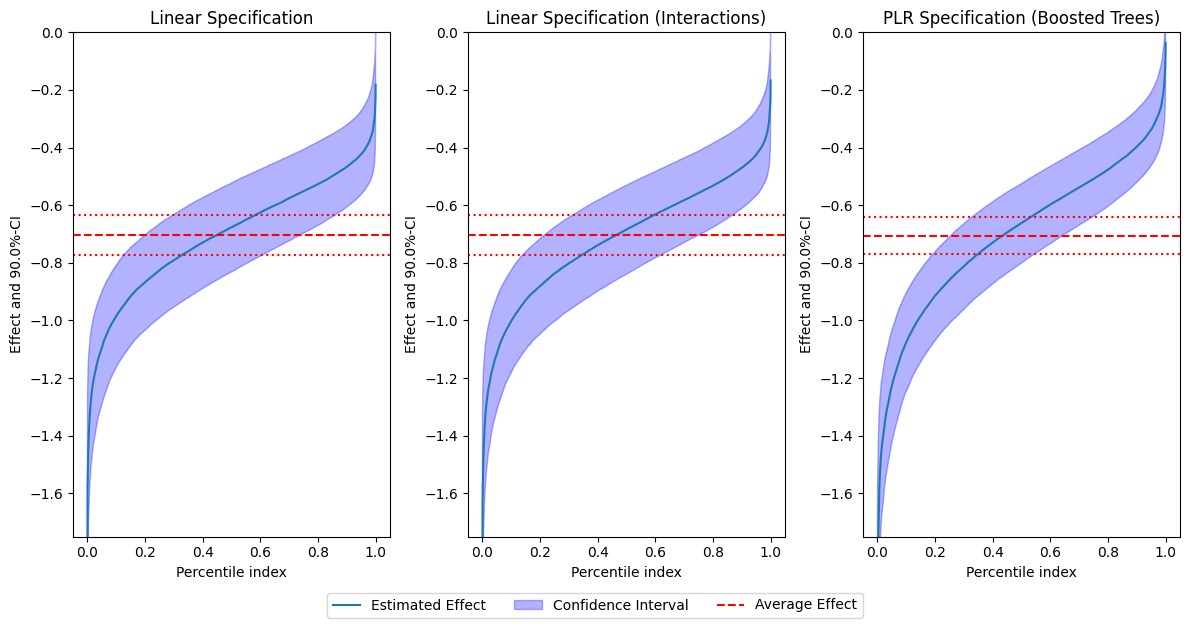

Sorted Effects for pca_10_components


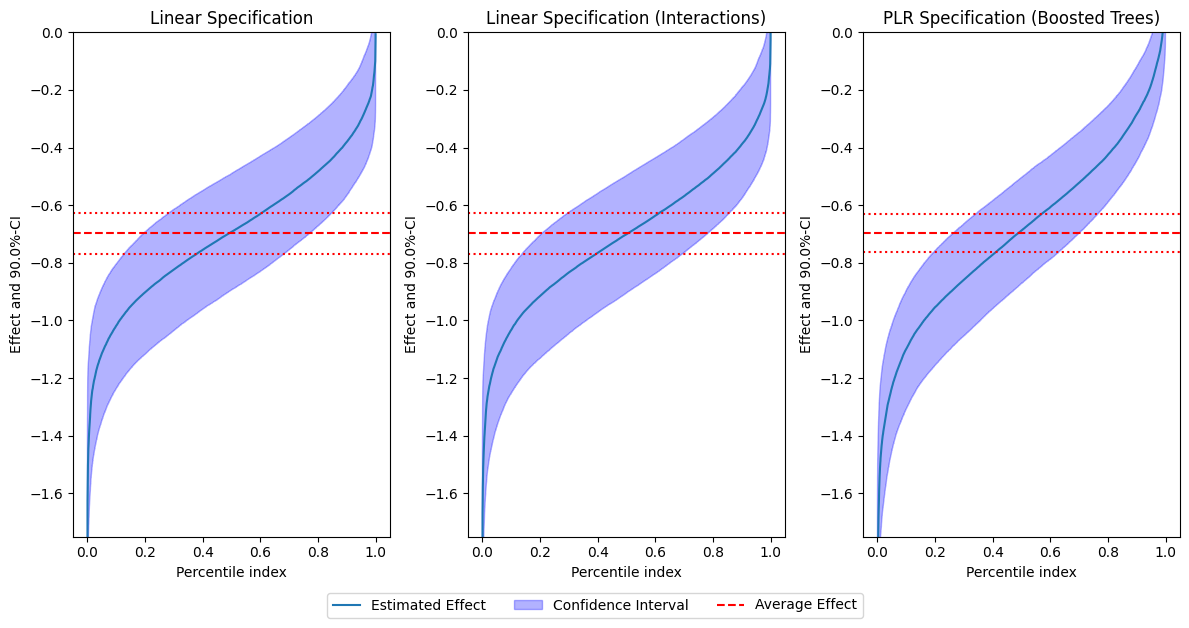

Sorted Effects for pca_20_components


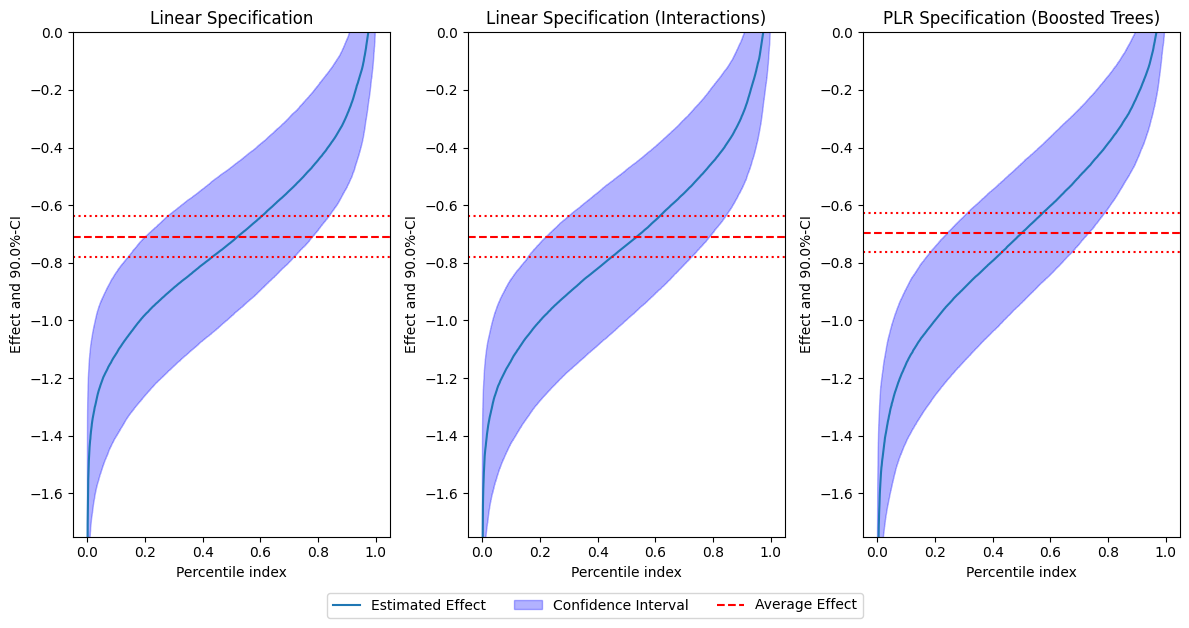

In [174]:
for (nme, cate_models_polynomial_i), pca_vars_i in zip(
    cate_models_polynomial.items(), 
    [pca_05_vars, pca_10_vars, pca_20_vars]
    ):
    
    print(f"Sorted Effects for {nme}")
    plot_sorted_func(cate_models_polynomial_i, pca_vars_i)